# eHMM-Guided Transformer for Electricity Demand Forecasting

 lookback=168h | horizon sweep H∈{24,72,168} | K* via BIC | FiLM per-timestep

In [4]:
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

ROOT = Path("..").resolve()
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"

for d in [DATA_RAW, DATA_PROCESSED, FIG_DIR, MODEL_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CACHE_TRAIN = DATA_PROCESSED / "processed_train.parquet"
CACHE_VAL = DATA_PROCESSED / "processed_val.parquet"
CACHE_TEST = DATA_PROCESSED / "processed_test.parquet"
CACHE_TRAIN_REGIME = DATA_PROCESSED / "processed_train_with_regime.parquet"
CACHE_VAL_REGIME = DATA_PROCESSED / "processed_val_with_regime.parquet"
CACHE_TEST_REGIME = DATA_PROCESSED / "processed_test_with_regime.parquet"


def processed_cache_exists() -> bool:
    return CACHE_TRAIN.exists() and CACHE_VAL.exists() and CACHE_TEST.exists()


def regime_cache_exists() -> bool:
    return (
        CACHE_TRAIN_REGIME.exists()
        and CACHE_VAL_REGIME.exists()
        and CACHE_TEST_REGIME.exists()
    )

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

CONFIG = {
    "top_n_meters": 1,
    "train_ratio": 0.70,
    "val_ratio": 0.10,
    "test_ratio": 0.20,
    "input_window": 168,
    "forecast_horizon": 24,
    "use_lag_rolling_features": False,  # False = bỏ lag/rolling khỏi model input (tạm thời, công bằng hơn cho Transformer)
    "n_states": 3,  # overwritten by HMM BIC search when run_hmm_opt=True
    "n_ensemble": 3,
    "run_hmm_opt": False,
    "hmm_k_candidates": [2, 3, 4, 5],
    "run_forecast_k_selection": False,  # refine K*/F* among top-BIC by short forecast val
    "hmm_topk_bic": 3,
    "k_select_epochs": 12,
    "d_model": 128,
    "n_heads": 8,
    "num_layers": 3,
    "dim_feedforward": 256,
    "dropout": 0.1,
    "batch_size": 16,  # nhỏ hơn để giảm peak RAM trên Mac MPS
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 50,
    "patience": 10,
    "grad_clip": 1.0,
    # --- Phase toggles (chạy từng phase, restart kernel giữa chừng nếu RAM thấp) ---
    "run_hpo": False,
    "run_main_models": False,       # eHMM + Vanilla Transformer
    "run_lightgbm_baseline": False,  # thay XGBoost (crash) — LightGBM nhẹ hơn
    "run_heavy_baselines": False,  # PatchTST + SimpleTFT + iTransformer — bật riêng sau
    "run_eval_only": True,        # False = train; True = chỉ eval + plot
    "use_paper_metrics": True,     # True = load outputs/metrics_paper.csv (Table 1) thay vì tính từ .npz
    "baseline_max_epochs": 30,
    # --- OOM safety ---
    "skip_existing_checkpoints": False,  # có .pt/.npz thì không train lại
    "free_models_after_predict": True,  # predict → save disk → del model
    # --- Horizon sweep (Phase 6.5) ---
    "run_horizon_sweep": False,
    "horizon_sweep": [24, 72, 168],
    "run_sweep_naive": False,
    "run_sweep_lightgbm": False,
    "run_sweep_heavy_baselines": False,  # PatchTST + SimpleTFT + iTransformer per H
}

print(f"Device: {DEVICE}")
print(f"Root: {ROOT}")
print("Phase flags:", {k: CONFIG[k] for k in [
    "use_paper_metrics",
    "run_horizon_sweep", "horizon_sweep", "forecast_horizon",
    "run_hmm_opt", "run_hpo", "run_main_models", "run_lightgbm_baseline", "run_heavy_baselines", "run_eval_only",
    "skip_existing_checkpoints", "free_models_after_predict",
]})


Device: mps
Root: /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting
Phase flags: {'use_paper_metrics': True, 'run_horizon_sweep': False, 'horizon_sweep': [24, 72, 168], 'forecast_horizon': 24, 'run_hmm_opt': False, 'run_hpo': False, 'run_main_models': False, 'run_lightgbm_baseline': False, 'run_heavy_baselines': False, 'run_eval_only': True, 'skip_existing_checkpoints': False, 'free_models_after_predict': True}


## Phase 1: Dataset Pipeline

In [5]:
import sys

DATA_FILES = ("demand.parquet", "metadata.parquet", "weather.parquet")


def resolve_data_paths(raw_dir: Path) -> dict[str, Path]:
    """Resolve parquet paths (supports data/raw/ and data/raw/data/)."""
    paths = {}
    for name in DATA_FILES:
        direct = raw_dir / name
        nested = raw_dir / "data" / name
        if direct.exists():
            paths[name] = direct
        elif nested.exists():
            paths[name] = nested
        else:
            paths[name] = direct
    return paths


def ensure_dataset(raw_dir: Path) -> dict[str, Path]:
    paths = resolve_data_paths(raw_dir)
    if all(p.exists() for p in paths.values()):
        return paths

    print("Dataset chua co. Dang thu download tu Hugging Face...")
    import subprocess

    result = subprocess.run(
        [sys.executable, str(ROOT / "scripts" / "download_data.py")],
        cwd=ROOT,
        capture_output=True,
        text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise FileNotFoundError(
            "Khong tai duoc dataset.\n"
            "Buoc 1: https://huggingface.co/datasets/EDS-lab/electricity-demand -> Accept terms\n"
            "Buoc 2: hf auth login\n"
            "Buoc 3: python scripts/download_data.py"
        )

    paths = resolve_data_paths(raw_dir)
    missing = [p for p in paths.values() if not p.exists()]
    if missing:
        raise FileNotFoundError(f"Van thieu file: {missing}")
    return paths


def load_raw_tables(raw_dir: Path):
    """Load demand/metadata/weather (~1GB). Only call when processed cache is missing."""
    paths = ensure_dataset(raw_dir)
    demand = pd.read_parquet(paths["demand.parquet"])
    metadata = pd.read_parquet(paths["metadata.parquet"])
    weather = pd.read_parquet(paths["weather.parquet"])
    return demand, metadata, weather


# Skip raw load when processed parquet already exists (saves ~1GB RAM)
demand = metadata = weather = None
if processed_cache_exists():
    print("Processed cache found — skip raw load (demand.parquet ~1GB)")
else:
    print("No processed cache — loading raw tables...")
    demand, metadata, weather = load_raw_tables(DATA_RAW)
    print(demand.shape, metadata.shape, weather.shape)
    demand.head()


Processed cache found — skip raw load (demand.parquet ~1GB)


In [6]:
def select_top_meters_fast(demand_df, metadata_df, top_n=1):
    """
    Select best meter IDs directly from demand + metadata (no weather join needed).
    Operates on the raw demand table — much faster than filtering after full merge.
    """
    demand_df = demand_df.copy()
    demand_df["timestamp"] = pd.to_datetime(demand_df["timestamp"])

    stats = (
        demand_df.groupby("unique_id")
        .agg(
            n_rows=("y", "count"),
            missing_ratio=("y", lambda s: s.isna().mean()),
            start=("timestamp", "min"),
            end=("timestamp", "max"),
        )
        .reset_index()
    )
    stats["duration_days"] = (stats["end"] - stats["start"]).dt.days
    stats = stats.sort_values(
        ["missing_ratio", "n_rows", "duration_days"],
        ascending=[True, False, False],
    )
    return stats.head(top_n)["unique_id"].tolist()


def merge_datasets(demand_df, metadata_df, weather_df):
    """Merge after demand is already filtered to selected meters."""
    df = demand_df.merge(metadata_df, on="unique_id", how="inner")
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    weather_df = weather_df.copy()
    weather_df["timestamp"] = pd.to_datetime(weather_df["timestamp"])
    df = df.merge(weather_df, on=["location_id", "timestamp"], how="left")
    return df.sort_values(["unique_id", "timestamp"]).reset_index(drop=True)


def resample_hourly(df):
    frames = []
    weather_cols = [
        c for c in df.columns
        if c not in ["unique_id", "timestamp", "y"] and pd.api.types.is_numeric_dtype(df[c])
    ]
    meta_cols = [c for c in df.columns if c not in weather_cols + ["timestamp", "y"]]

    for uid, g in df.groupby("unique_id"):
        g = g.set_index("timestamp").sort_index()
        agg = {"y": "sum"}
        for c in weather_cols:
            agg[c] = "mean"
        hourly = g.resample("1h").agg(agg)
        for c in meta_cols:
            if c != "unique_id":
                hourly[c] = g[c].iloc[0]
        hourly["unique_id"] = uid
        hourly = hourly.reset_index()
        frames.append(hourly)
    return pd.concat(frames, ignore_index=True)


def handle_missing(df, max_gap_hours=6):
    df = df.sort_values(["unique_id", "timestamp"]).copy()
    weather_cols = [
        "temperature_2m", "relative_humidity_2m", "apparent_temperature",
        "precipitation", "rain", "snowfall", "dew_point_2m",
    ]
    weather_cols = [c for c in weather_cols if c in df.columns]

    frames = []
    for uid, g in df.groupby("unique_id"):
        g = g.set_index("timestamp").sort_index()
        full_idx = pd.date_range(g.index.min(), g.index.max(), freq="1h")
        g = g.reindex(full_idx)
        g["unique_id"] = uid

        missing_mask = g["y"].isna()
        if missing_mask.any():
            gap_id = (missing_mask != missing_mask.shift()).cumsum()
            gap_sizes = missing_mask.groupby(gap_id).transform("sum")
            g.loc[gap_sizes > max_gap_hours, "y"] = np.nan
        g["y"] = g["y"].interpolate(method="linear", limit=max_gap_hours)
        g = g.dropna(subset=["y"])

        for c in weather_cols:
            g[c] = g[c].ffill().bfill()
        frames.append(g.reset_index().rename(columns={"index": "timestamp"}))
    return pd.concat(frames, ignore_index=True)


def add_time_features(df):
    df = df.copy()
    ts = df["timestamp"]
    df["hour"] = ts.dt.hour
    df["day_of_week"] = ts.dt.dayofweek
    df["month"] = ts.dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
    return df


def add_lag_rolling_features(df):
    df = df.sort_values(["unique_id", "timestamp"]).copy()
    g = df.groupby("unique_id")["y"]
    df["y_lag_1"] = g.shift(1)
    df["y_lag_24"] = g.shift(24)
    df["y_lag_168"] = g.shift(168)
    df["rolling_mean_24"] = g.transform(lambda s: s.shift(1).rolling(24, min_periods=1).mean())
    df["rolling_std_24"] = g.transform(lambda s: s.shift(1).rolling(24, min_periods=1).std()).fillna(0)
    df["rolling_mean_168"] = g.transform(lambda s: s.shift(1).rolling(168, min_periods=1).mean())
    df["rolling_std_168"] = g.transform(lambda s: s.shift(1).rolling(168, min_periods=1).std()).fillna(0)
    return df.dropna().reset_index(drop=True)


def chronological_split(df, train_ratio=0.7, val_ratio=0.1):
    df = df.sort_values("timestamp").reset_index(drop=True)
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

In [7]:
if processed_cache_exists():
    print("Loading cached processed data...")
    train_df = pd.read_parquet(CACHE_TRAIN)
    val_df = pd.read_parquet(CACHE_VAL)
    test_df = pd.read_parquet(CACHE_TEST)
    selected_ids = train_df["unique_id"].unique().tolist()
else:
    if demand is None:
        print("Raw tables not in memory — loading now...")
        demand, metadata, weather = load_raw_tables(DATA_RAW)

    print("Step 1/6: Selecting best meters (fast, no weather join)...")
    selected_ids = select_top_meters_fast(demand, metadata, top_n=CONFIG["top_n_meters"])
    print(f"  Selected: {selected_ids}")

    print("Step 2/6: Filtering demand to selected meters...")
    demand_sub = demand[demand["unique_id"].isin(selected_ids)].copy()
    print(f"  Demand subset: {len(demand_sub):,} rows")

    print("Step 3/6: Merging with metadata and weather...")
    df = merge_datasets(demand_sub, metadata, weather)
    del demand_sub

    print("Step 4/6: Resample + missing values + features...")
    df = resample_hourly(df)
    df = handle_missing(df)
    df = add_time_features(df)
    df = add_lag_rolling_features(df)

    print("Step 5/6: Chronological split...")
    train_df, val_df, test_df = chronological_split(
        df,
        train_ratio=CONFIG["train_ratio"],
        val_ratio=CONFIG["val_ratio"],
    )
    del df

    print("Step 6/6: Saving to cache...")
    train_df.to_parquet(CACHE_TRAIN, index=False)
    val_df.to_parquet(CACHE_VAL, index=False)
    test_df.to_parquet(CACHE_TEST, index=False)

    # Free raw tables immediately after processing
    del demand, metadata, weather
    demand = metadata = weather = None
    import gc
    gc.collect()
    print("Freed raw tables from memory")

print(f"\nSelected meters: {selected_ids}")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
train_df.head()


Loading cached processed data...

Selected meters: ['0000402b3d8bb6f6']
Train: 24,427 | Val: 3,490 | Test: 6,980


,timestamp,y,latitude,longitude,cluster_size,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,...,hour_cos,dow_sin,dow_cos,y_lag_1,y_lag_24,y_lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_std_168
0,2011-01-08 00:00:00,168.284790,40.29,1.73,1.0,13.5425,86.483841,11.317499,10.479946,0.50,...,1.000000,-0.974928,-0.222521,289.644013,143.689320,61.650485,275.451726,78.408754,255.052782,82.288988
1,2011-01-08 01:00:00,145.954693,40.29,1.73,1.0,13.7175,85.242355,11.267500,10.315918,0.90,...,0.965926,-0.974928,-0.222521,168.284790,123.139159,119.741100,276.476537,76.755021,255.687510,81.192213
2,2011-01-08 02:00:00,141.747573,40.29,1.73,1.0,13.6675,84.851807,11.142500,10.074484,0.80,...,0.866025,-0.974928,-0.222521,145.954693,120.873786,114.239482,277.427184,74.891973,255.843543,80.954230
3,2011-01-08 03:00:00,141.100324,40.29,1.73,1.0,13.5925,86.868904,11.417500,9.353476,1.55,...,0.707107,-0.974928,-0.222521,141.747573,123.948220,115.048544,278.296926,73.094463,256.007282,80.693504
4,2011-01-08 04:00:00,182.362460,40.29,1.73,1.0,13.8425,87.089432,11.692499,9.105686,1.75,...,0.500000,-0.974928,-0.222521,141.100324,157.281553,115.210356,279.011597,71.588054,256.162352,80.445651


## Phase 2: Optimized Ensemble HMM Regime Encoder

1. **Search** — sweep `K ∈ {2,3,4,5}` × feature sets (`full`, `load_only`) using single-HMM **BIC** (fit on train).
2. **Fit** — train the block-bootstrap **EnsembleHMM** with selected `K*` and feature set `F*`.
3. **Emit** — soft posterior probabilities for all timesteps (dynamic `REGIME_NAMES`).

In [8]:
# Candidate HMM feature sets (search space for F*)
HMM_FEATURES_FULL = [
    "y", "y_lag_24", "rolling_mean_24", "rolling_std_24",
    "temperature_2m", "hour_sin", "hour_cos", "dow_sin", "dow_cos",
]
HMM_FEATURES_FULL = [c for c in HMM_FEATURES_FULL if c in train_df.columns]

HMM_FEATURES_LOAD_ONLY = [
    "y", "y_lag_24", "rolling_mean_24", "rolling_std_24",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
]
HMM_FEATURES_LOAD_ONLY = [c for c in HMM_FEATURES_LOAD_ONLY if c in train_df.columns]

HMM_FEATURE_CANDIDATES = {
    "full": HMM_FEATURES_FULL,
    "load_only": HMM_FEATURES_LOAD_ONLY,
}


def get_regime_names(n_states):
    labels = ["low", "normal", "peak", "very_high", "extreme"]
    if n_states <= len(labels):
        return [f"regime_{labels[i]}_prob" for i in range(n_states)]
    return [f"regime_{i}_prob" for i in range(n_states)]


def hmm_n_free_params(n_states, n_features, covariance_type="diag"):
    """Number of free parameters for a GaussianHMM (start + trans + emission)."""
    start = n_states - 1
    trans = n_states * (n_states - 1)
    means = n_states * n_features
    if covariance_type == "diag":
        covars = n_states * n_features
    elif covariance_type == "full":
        covars = n_states * n_features * (n_features + 1) // 2
    elif covariance_type == "spherical":
        covars = n_states
    else:  # tied
        covars = n_features * (n_features + 1) // 2
    return start + trans + means + covars


def fit_single_hmm_for_bic(X, n_states, random_state=42, n_iter=100):
    model = GaussianHMM(
        n_components=n_states,
        covariance_type="diag",
        n_iter=n_iter,
        random_state=random_state,
    )
    model.fit(X)
    return model


def score_hmm_bic(model, X):
    """BIC = -2 * LL + p * log(n). Lower is better."""
    n = len(X)
    ll = model.score(X)  # total log-likelihood of the sequence
    p = hmm_n_free_params(model.n_components, X.shape[1], model.covariance_type)
    return -2.0 * ll + p * np.log(n), ll, p


def optimize_hmm_config(
    train_df,
    feature_candidates,
    k_candidates,
    random_state=42,
):
    """
    Grid-search Optimal states K* and feature set F* via single-HMM BIC on train.
    Returns best config dict + full results DataFrame.
    """
    rows = []
    for feat_name, feats in feature_candidates.items():
        if not feats:
            continue
        scaler = StandardScaler()
        X = scaler.fit_transform(train_df[feats].values)
        for K in k_candidates:
            try:
                model = fit_single_hmm_for_bic(X, K, random_state=random_state)
                bic, ll, n_params = score_hmm_bic(model, X)
                rows.append(
                    {
                        "feature_set": feat_name,
                        "n_states": K,
                        "n_features": len(feats),
                        "log_likelihood": ll,
                        "n_params": n_params,
                        "bic": bic,
                        "converged": bool(getattr(model.monitor_, "converged", True)),
                    }
                )
                print(f"  BIC search: feats={feat_name:10s} K={K}  BIC={bic:,.1f}  LL={ll:,.1f}")
            except Exception as exc:
                rows.append(
                    {
                        "feature_set": feat_name,
                        "n_states": K,
                        "n_features": len(feats),
                        "log_likelihood": np.nan,
                        "n_params": np.nan,
                        "bic": np.inf,
                        "converged": False,
                        "error": str(exc),
                    }
                )
                print(f"  BIC search FAILED: feats={feat_name} K={K} — {exc}")

    results = pd.DataFrame(rows).sort_values("bic").reset_index(drop=True)
    best = results.iloc[0]
    return {
        "feature_set": best["feature_set"],
        "n_states": int(best["n_states"]),
        "bic": float(best["bic"]),
        "features": list(feature_candidates[best["feature_set"]]),
    }, results


class EnsembleHMM:
    def __init__(self, n_models=5, n_states=3, random_state=42):
        self.n_models = n_models
        self.n_states = n_states
        self.random_state = random_state
        self.models = []
        self.scaler = StandardScaler()
        self.state_order = None

    def _fit_single(self, X, lengths, seed):
        model = GaussianHMM(
            n_components=self.n_states,
            covariance_type="diag",
            n_iter=100,
            random_state=seed,
        )
        model.fit(X, lengths=lengths)
        return model

    def fit(self, df, feature_cols, y_col="y", window_size=168):
        X = self.scaler.fit_transform(df[feature_cols].values)
        self.models = []
        rng = np.random.RandomState(self.random_state)

        n_windows = max(1, len(X) - window_size + 1)
        n_blocks = max(1, len(X) // window_size)
        for i in range(self.n_models):
            print(f"Fitting HMM {i + 1}/{self.n_models} (block bootstrap: {n_blocks} blocks x {window_size})...")
            starts = rng.choice(n_windows, size=n_blocks, replace=True)
            X_boot = np.concatenate([X[s : s + window_size] for s in starts], axis=0)
            lengths = [window_size] * n_blocks
            model = self._fit_single(X_boot, lengths, seed=self.random_state + i)
            self.models.append(model)

        posteriors = self._ensemble_posteriors(X)
        hard = posteriors.argmax(axis=1)
        state_means = []
        for s in range(self.n_states):
            mask = hard == s
            state_means.append(df.loc[mask, y_col].mean() if mask.any() else np.inf)
        self.state_order = np.argsort(state_means)
        return self

    def _ensemble_posteriors(self, X):
        probs = []
        for model in self.models:
            p = model.predict_proba(X)
            probs.append(p)
        return np.mean(probs, axis=0)

    def _reorder_probs(self, probs):
        return probs[:, self.state_order]

    def predict_proba(self, df, feature_cols):
        X = self.scaler.transform(df[feature_cols].values)
        probs = self._ensemble_posteriors(X)
        return self._reorder_probs(probs)

    def append_regime_probs(self, df, feature_cols):
        """Append soft regime probs with dynamic column names for any K."""
        out = df.copy()
        probs = self.predict_proba(out, feature_cols)
        names = get_regime_names(self.n_states)
        for i, col in enumerate(names):
            out[col] = probs[:, i]
        out["regime_hard_label"] = probs.argmax(axis=1)
        return out


class SingleHMM:
    """Single Gaussian HMM for ablation (no ensemble bootstrap)."""

    def __init__(self, n_states=3, random_state=42):
        self.n_states = n_states
        self.random_state = random_state
        self.model = None
        self.scaler = StandardScaler()
        self.state_order = None

    def fit(self, df, feature_cols, y_col="y"):
        X = self.scaler.fit_transform(df[feature_cols].values)
        self.model = GaussianHMM(
            n_components=self.n_states,
            covariance_type="diag",
            n_iter=200,
            random_state=self.random_state,
        )
        self.model.fit(X)
        probs = self.model.predict_proba(X)
        hard = probs.argmax(axis=1)
        state_means = []
        for s in range(self.n_states):
            mask = hard == s
            state_means.append(df.loc[mask, y_col].mean() if mask.any() else np.inf)
        self.state_order = np.argsort(state_means)
        return self

    def _reorder_probs(self, probs):
        return probs[:, self.state_order]

    def predict_proba(self, df, feature_cols):
        X = self.scaler.transform(df[feature_cols].values)
        return self._reorder_probs(self.model.predict_proba(X))

    def append_regime_probs(self, df, feature_cols, prefix="regime"):
        out = df.copy()
        probs = self.predict_proba(out, feature_cols)
        for i in range(self.n_states):
            out[f"{prefix}_prob_{i}"] = probs[:, i]
        out[f"{prefix}_hard_label"] = probs.argmax(axis=1)
        return out


def append_ensemble_regime_probs(ehmm_obj, df, feature_cols, n_states):
    """Append regime probs with dynamic column names for ablation sweeps."""
    out = df.copy()
    probs = ehmm_obj.predict_proba(out, feature_cols)
    names = get_regime_names(n_states)
    for i, col in enumerate(names):
        out[col] = probs[:, i]
    out["regime_hard_label"] = probs.argmax(axis=1)
    return out, names


# --- Step 1: Optimize K* and F* via BIC ---
RUN_HMM_OPT = CONFIG.get("run_hmm_opt", True)
K_CANDIDATES = CONFIG.get("hmm_k_candidates", [2, 3, 4, 5])

if RUN_HMM_OPT:
    print("Optimizing Ensemble HMM config (single-HMM BIC grid search)...")
    best_hmm, hmm_opt_df = optimize_hmm_config(
        train_df,
        HMM_FEATURE_CANDIDATES,
        K_CANDIDATES,
        random_state=SEED,
    )
    CONFIG["n_states"] = best_hmm["n_states"]
    HMM_FEATURES = best_hmm["features"]
    HMM_FEATURE_SET_NAME = best_hmm["feature_set"]
    hmm_opt_df.to_csv(OUTPUT_DIR / "hmm_bic_search.csv", index=False)
    # Top-K candidates by BIC — refined later by short forecast validation (Phase 5.0).
    _topk = CONFIG.get("hmm_topk_bic", 3)
    HMM_TOPK_CANDIDATES = (
        hmm_opt_df.head(_topk)[["feature_set", "n_states"]]
        .assign(n_states=lambda d: d["n_states"].astype(int))
        .to_dict("records")
    )
    print(
        f"\nBIC-best: feature_set={HMM_FEATURE_SET_NAME}, "
        f"K*={CONFIG['n_states']}, BIC={best_hmm['bic']:,.1f}"
    )
    print(f"Top-{_topk} BIC candidates (for forecast refinement): {HMM_TOPK_CANDIDATES}")
    display(hmm_opt_df)
else:
    HMM_FEATURES = list(HMM_FEATURES_FULL)
    HMM_FEATURE_SET_NAME = "full"
    HMM_TOPK_CANDIDATES = []
    print(f"HMM opt skipped — using defaults: K={CONFIG['n_states']}, features={HMM_FEATURE_SET_NAME}")

REGIME_NAMES = get_regime_names(CONFIG["n_states"])
print(f"REGIME_NAMES ({len(REGIME_NAMES)}): {REGIME_NAMES}")
print(f"HMM_FEATURES ({len(HMM_FEATURES)}): {HMM_FEATURES}")

# --- Step 2: Fit EnsembleHMM with K*, F* ---
ehmm = EnsembleHMM(
    n_models=CONFIG["n_ensemble"],
    n_states=CONFIG["n_states"],
    random_state=SEED,
)
ehmm.fit(train_df, HMM_FEATURES)

train_df = ehmm.append_regime_probs(train_df, HMM_FEATURES)
val_df = ehmm.append_regime_probs(val_df, HMM_FEATURES)
test_df = ehmm.append_regime_probs(test_df, HMM_FEATURES)

train_df.to_parquet(DATA_PROCESSED / "processed_train_with_regime.parquet", index=False)
val_df.to_parquet(DATA_PROCESSED / "processed_val_with_regime.parquet", index=False)
test_df.to_parquet(DATA_PROCESSED / "processed_test_with_regime.parquet", index=False)

pd.DataFrame(
    [
        {
            "feature_set": HMM_FEATURE_SET_NAME,
            "n_states": CONFIG["n_states"],
            "n_ensemble": CONFIG["n_ensemble"],
            "hmm_features": ",".join(HMM_FEATURES),
            "regime_names": ",".join(REGIME_NAMES),
        }
    ]
).to_csv(OUTPUT_DIR / "best_hmm_config.csv", index=False)

train_df[["y"] + REGIME_NAMES + ["regime_hard_label"]].head()


HMM opt skipped — using defaults: K=3, features=full
REGIME_NAMES (3): ['regime_low_prob', 'regime_normal_prob', 'regime_peak_prob']
HMM_FEATURES (9): ['y', 'y_lag_24', 'rolling_mean_24', 'rolling_std_24', 'temperature_2m', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
Fitting HMM 1/3 (block bootstrap: 145 blocks x 168)...
Fitting HMM 2/3 (block bootstrap: 145 blocks x 168)...
Fitting HMM 3/3 (block bootstrap: 145 blocks x 168)...


,y,regime_low_prob,regime_normal_prob,regime_peak_prob,regime_hard_label
0,168.284790,0.666667,0.333333,6.848294e-11,0
1,145.954693,0.666667,0.333333,2.045863e-14,0
2,141.747573,0.666667,0.333333,5.336971e-15,0
3,141.100324,0.666667,0.333333,4.512884e-15,0
4,182.362460,0.666662,0.333338,1.054333e-11,0


## Phase 3: Forecasting Dataset

In [9]:
LAG_ROLLING_FEATURES = [
    "y_lag_1", "y_lag_24", "y_lag_168",
    "rolling_mean_24", "rolling_std_24", "rolling_mean_168", "rolling_std_168",
]

_ALL_BASE_FEATURES = [
    "y",
    *LAG_ROLLING_FEATURES,
    "temperature_2m", "relative_humidity_2m", "apparent_temperature",
    "precipitation", "rain", "snowfall",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_day",
]

if CONFIG.get("use_lag_rolling_features", True):
    BASE_FEATURES = _ALL_BASE_FEATURES
else:
    BASE_FEATURES = [c for c in _ALL_BASE_FEATURES if c not in LAG_ROLLING_FEATURES]

BASE_FEATURES = [c for c in BASE_FEATURES if c in train_df.columns]
PROPOSED_FEATURES = BASE_FEATURES + REGIME_NAMES
TARGET_COL = "y"

if not CONFIG.get("use_lag_rolling_features", True):
    dropped = [c for c in LAG_ROLLING_FEATURES if c in train_df.columns]
    print(f"Lag/rolling excluded from model input ({len(dropped)}): {dropped}")


class ForecastDataset(Dataset):
    def __init__(self, df, feature_cols, target_col, input_window, horizon):
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.input_window = input_window
        self.horizon = horizon
        self.X, self.y = self._build_windows(df)

    def _build_windows(self, df):
        df = df.sort_values("timestamp").reset_index(drop=True)
        feats = df[self.feature_cols].values.astype(np.float32)
        target = df[self.target_col].values.astype(np.float32)
        X_list, y_list = [], []
        total = len(df) - self.input_window - self.horizon + 1
        for i in range(total):
            X_list.append(feats[i : i + self.input_window])
            y_list.append(target[i + self.input_window : i + self.input_window + self.horizon])
        return np.stack(X_list), np.stack(y_list)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.from_numpy(self.y[idx])


def make_dataloaders(train_df, val_df, test_df, feature_cols, batch_size):
    iw, hz = CONFIG["input_window"], CONFIG["forecast_horizon"]
    train_ds = ForecastDataset(train_df, feature_cols, TARGET_COL, iw, hz)
    val_ds = ForecastDataset(val_df, feature_cols, TARGET_COL, iw, hz)
    test_ds = ForecastDataset(test_df, feature_cols, TARGET_COL, iw, hz)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader


proposed_train_ds, proposed_val_ds, proposed_test_ds, proposed_train_loader, proposed_val_loader, proposed_test_loader = make_dataloaders(
    train_df, val_df, test_df, PROPOSED_FEATURES, CONFIG["batch_size"]
)
vanilla_train_ds, vanilla_val_ds, vanilla_test_ds, vanilla_train_loader, vanilla_val_loader, vanilla_test_loader = make_dataloaders(
    train_df, val_df, test_df, BASE_FEATURES, CONFIG["batch_size"]
)

x_sample, y_sample = proposed_train_ds[0]
print(f"X: {x_sample.shape} | y: {y_sample.shape}")
print(f"Proposed features: {len(PROPOSED_FEATURES)} | Vanilla features: {len(BASE_FEATURES)}")

Lag/rolling excluded from model input (7): ['y_lag_1', 'y_lag_24', 'y_lag_168', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168', 'rolling_std_168']
X: torch.Size([168, 15]) | y: torch.Size([24])
Proposed features: 15 | Vanilla features: 12


## Phase 4: Transformer Model

In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)


class RegimeGuidedTransformer(nn.Module):
    def __init__(
        self,
        num_features,
        d_model=128,
        n_heads=8,
        num_layers=3,
        dim_feedforward=256,
        dropout=0.1,
        horizon=24,
    ):
        super().__init__()
        self.input_projection = nn.Linear(num_features, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, horizon),
        )

    def forward(self, x):
        h = self.input_projection(x)
        h = self.positional_encoding(h)
        h = self.encoder(h)
        h_last = h[:, -1, :]
        return self.head(h_last)


class RegimeFiLMAttention(nn.Module):
    """Multi-head self-attention with regime-conditioned FiLM on Q, K, V (eq. 7-9)."""

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model must be divisible by n_heads")
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.scale = self.head_dim ** -0.5

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.film_q = nn.Linear(d_model, 2 * d_model)
        self.film_k = nn.Linear(d_model, 2 * d_model)
        self.film_v = nn.Linear(d_model, 2 * d_model)
        for film in (self.film_q, self.film_k, self.film_v):
            nn.init.zeros_(film.weight)
            nn.init.zeros_(film.bias)

        self.dropout = nn.Dropout(dropout)

    def _apply_film(self, tensor, gamma, beta):
        # gamma/beta: (batch, T, d_model) for per-timestep FiLM, or
        # (batch, d_model) which is broadcast across all timesteps.
        if gamma.dim() == 2:
            gamma = gamma.unsqueeze(1)
            beta = beta.unsqueeze(1)
        return (1.0 + gamma) * tensor + beta

    def forward(self, x, regime_embed):
        b, t, _ = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        gamma_q, beta_q = self.film_q(regime_embed).chunk(2, dim=-1)
        gamma_k, beta_k = self.film_k(regime_embed).chunk(2, dim=-1)
        gamma_v, beta_v = self.film_v(regime_embed).chunk(2, dim=-1)

        q = self._apply_film(q, gamma_q, beta_q)
        k = self._apply_film(k, gamma_k, beta_k)
        v = self._apply_film(v, gamma_v, beta_v)

        q = q.view(b, t, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(b, t, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(b, t, self.n_heads, self.head_dim).transpose(1, 2)

        attn = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attn = torch.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, v)

        out = out.transpose(1, 2).contiguous().view(b, t, self.d_model)
        return self.out_proj(out)


class RegimeAwareEncoderLayer(nn.Module):
    """Transformer encoder layer with regime-aware attention."""

    def __init__(self, d_model, n_heads, dim_feedforward, dropout=0.1):
        super().__init__()
        self.self_attn = RegimeFiLMAttention(d_model, n_heads, dropout)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, regime_embed):
        attn_out = self.self_attn(x, regime_embed)
        x = self.norm1(x + self.dropout1(attn_out))
        ff = self.linear2(self.dropout(torch.relu(self.linear1(x))))
        x = self.norm2(x + self.dropout2(ff))
        return x


class RegimeGatedTransformer(nn.Module):
    """
    Regime-Aware Transformer (Section 3.5).

    The encoder processes only base features. Regime probabilities r_t at
    every timestep (all T steps in the lookback window) are embedded (eq. 6)
    and used to FiLM-modulate Q, K, and V per-timestep inside multi-head
    self-attention (eq. 7-9). The forecast head maps the last-token
    representation to H future demand values (eq. 10).

    Input layout: x[..., :num_base_features] are base features,
    x[..., num_base_features:] are the K regime probabilities.
    """

    def __init__(
        self,
        num_base_features,
        num_regimes,
        d_model=128,
        n_heads=8,
        num_layers=3,
        dim_feedforward=256,
        dropout=0.1,
        horizon=24,
    ):
        super().__init__()
        self.num_base_features = num_base_features
        self.num_regimes = num_regimes

        self.input_projection = nn.Linear(num_base_features, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout=dropout)
        self.regime_embed = nn.Linear(num_regimes, d_model)  # eq. 6
        self.regime_dropout = nn.Dropout(dropout)  # regularize FiLM conditioning branch
        self.layers = nn.ModuleList(
            [
                RegimeAwareEncoderLayer(d_model, n_heads, dim_feedforward, dropout)
                for _ in range(num_layers)
            ]
        )

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, horizon),
        )

    def forward(self, x):
        base = x[..., : self.num_base_features]
        regime = x[..., self.num_base_features :]  # (batch, T, K) all timesteps

        e_r = self.regime_dropout(self.regime_embed(regime))  # eq. 6 -> (batch, T, d_model)

        h = self.input_projection(base)
        h = self.positional_encoding(h)
        for layer in self.layers:
            h = layer(h, e_r)

        h_last = h[:, -1, :]
        return self.head(h_last)

class PatchTST(nn.Module):
    """Simplified PatchTST: patch-based Transformer for time-series forecasting."""

    def __init__(
        self,
        num_features,
        seq_len=168,
        patch_len=24,
        stride=12,
        d_model=128,
        n_heads=8,
        num_layers=3,
        horizon=24,
        dropout=0.1,
    ):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.n_patches = (seq_len - patch_len) // stride + 1
        self.patch_proj = nn.Linear(patch_len * num_features, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Linear(self.n_patches * d_model, horizon)

    def forward(self, x):
        b, t, f = x.shape
        patches = x.unfold(1, self.patch_len, self.stride)
        patches = patches.permute(0, 1, 3, 2).reshape(b, -1, self.patch_len * f)
        h = self.pos_enc(self.patch_proj(patches))
        h = self.encoder(h)
        return self.head(h.flatten(1))


class GatedResidualNetwork(nn.Module):
    """GRN block inspired by TFT."""

    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.gate = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.skip = nn.Linear(input_dim, output_dim) if input_dim != output_dim else nn.Identity()
        self.norm = nn.LayerNorm(output_dim)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        h = self.dropout(h)
        return self.norm(torch.sigmoid(self.gate(h)) * self.fc2(h) + self.skip(x))


class SimpleTFT(nn.Module):
    """Lightweight TFT-inspired forecaster with GRN encoding."""

    def __init__(
        self,
        num_features,
        d_model=128,
        n_heads=8,
        num_layers=2,
        horizon=24,
        dropout=0.1,
    ):
        super().__init__()
        self.input_grn = GatedResidualNetwork(num_features, d_model, d_model, dropout)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_grn = GatedResidualNetwork(d_model, d_model, d_model, dropout)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        h = self.input_grn(x)
        h = self.pos_enc(h)
        h = self.encoder(h)
        h_last = self.output_grn(h[:, -1, :])
        return self.head(h_last)


class ITransformer(nn.Module):
    """
    Simplified iTransformer (Liu et al., ICLR 2024 Spotlight).
    Inverts attention: each feature channel is a variate token; self-attention
    captures multivariate correlations. Forecasts target channel (y = index 0).

    Paper/code: https://github.com/thuml/iTransformer
    """

    def __init__(
        self,
        num_features,
        seq_len=168,
        d_model=128,
        n_heads=8,
        num_layers=2,
        dim_feedforward=256,
        horizon=24,
        dropout=0.1,
        use_norm=True,
        target_idx=0,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.horizon = horizon
        self.use_norm = use_norm
        self.target_idx = target_idx
        self.value_embedding = nn.Linear(seq_len, d_model)
        self.dropout = nn.Dropout(dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.projector = nn.Linear(d_model, horizon)

    def forward(self, x):
        # x: [B, L, N]
        if self.use_norm:
            means = x.mean(dim=1, keepdim=True).detach()
            x = x - means
            stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + 1e-5)
            x = x / stdev

        # invert: [B, N, L] then embed lookback -> [B, N, D]
        x_inv = x.permute(0, 2, 1)
        h = self.dropout(self.value_embedding(x_inv))
        h = self.encoder(h)
        # [B, N, H]
        out = self.projector(h)

        if self.use_norm:
            std_t = stdev[:, 0, self.target_idx].unsqueeze(-1)
            mean_t = means[:, 0, self.target_idx].unsqueeze(-1)
            y = out[:, self.target_idx, :] * std_t + mean_t
        else:
            y = out[:, self.target_idx, :]
        return y


## Phase 5: Training

In [11]:
def train_epoch(model, loader, optimizer, criterion, grad_clip=None):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        if grad_clip:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * len(xb)
        del xb, yb, pred, loss
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pred = model(xb)
        loss = criterion(pred, yb)
        total_loss += loss.item() * len(xb)
        del xb, yb, pred, loss
    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        pred = model(xb).cpu().numpy()
        preds.append(pred)
        trues.append(yb.numpy())
        del xb, pred
    return np.concatenate(preds), np.concatenate(trues)


def clear_torch_cache():
    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()


def release_model(model):
    """Move model to CPU then delete — reduces Mac unified-memory pressure."""
    if model is None:
        return None
    try:
        model.to("cpu")
    except Exception:
        pass
    del model
    clear_torch_cache()
    return None


def save_pred_arrays(name, preds, trues):
    path = PRED_DIR / f"{name}.npz"
    np.savez_compressed(path, preds=preds, trues=trues)
    print(f"Saved predictions → {path}")
    return path


def load_pred_arrays(name):
    path = PRED_DIR / f"{name}.npz"
    if not path.exists():
        return None, None
    data = np.load(path)
    return data["preds"], data["trues"]


METRICS_PATH = OUTPUT_DIR / "metrics.csv"
METRICS_BY_HORIZON_PATH = OUTPUT_DIR / "metrics_by_horizon.csv"
MANIFEST_PATH = OUTPUT_DIR / "run_manifest.json"


def pred_artifact_name(base, horizon=None):
    """Suffix predictions/checkpoints by horizon when running multi-H sweep."""
    if CONFIG.get("run_horizon_sweep", False):
        h = horizon if horizon is not None else CONFIG["forecast_horizon"]
        return f"{base}_h{h}"
    return base


def model_checkpoint_path(base, horizon=None):
    return MODEL_DIR / f"{pred_artifact_name(base, horizon)}.pt"


def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mape(y_true, y_pred, eps=1e-6):
    return float(np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100)


def smape(y_true, y_pred, eps=1e-6):
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return float(np.mean(2.0 * np.abs(y_true - y_pred) / denom) * 100)


def mase(y_true, y_pred, insample):
    naive_errors = np.abs(insample[1:] - insample[:-1])
    scale = np.mean(naive_errors) if len(naive_errors) > 0 else 1.0
    return float(np.mean(np.abs(y_true - y_pred)) / (scale + 1e-6))


def flatten_forecasts(y):
    return y.reshape(-1)


def compute_metrics(y_true, y_pred, insample):
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "MASE": mase(y_true, y_pred, insample),
    }


def compute_horizon_metrics_row(horizon, model_name, preds, trues, insample_y):
    """Build one row for metrics_by_horizon.csv from raw pred/true arrays."""
    m = compute_metrics(flatten_forecasts(trues), flatten_forecasts(preds), insample_y)
    return {"horizon": horizon, "model": model_name, **m}


def update_metrics_row(model_name, metrics_dict):
    """Ghi/merge 1 dòng metrics — an toàn khi chạy nhiều session."""
    cols = ["MAE", "RMSE", "MAPE", "sMAPE", "MASE"]
    row = {c: metrics_dict[c] for c in cols}
    if METRICS_PATH.exists():
        df = pd.read_csv(METRICS_PATH, index_col=0)
        df.loc[model_name] = row
    else:
        df = pd.DataFrame([row], index=[model_name])
    df = df[cols]
    df.to_csv(METRICS_PATH)
    print(f"Metrics updated → {METRICS_PATH.name} | {model_name}")
    return df


def record_metrics_from_cache(display_name, pred_key, insample_y):
    preds, trues = load_pred_arrays(pred_key)
    if preds is None or trues is None:
        print(f"Skip metrics: {display_name} (no {pred_key}.npz)")
        return None
    m = compute_metrics(flatten_forecasts(trues), flatten_forecasts(preds), insample_y)
    return update_metrics_row(display_name, m)


def save_train_history(pred_name, history):
    if not history or history.get("skipped"):
        return
    path = PRED_DIR / f"{pred_name}_history.npz"
    np.savez_compressed(path, train_loss=np.array(history["train_loss"]), val_loss=np.array(history["val_loss"]))
    print(f"Saved history → {path.name}")


def save_run_manifest(extra=None):
  import json
  from datetime import datetime
  artifacts = {
      "timestamp": datetime.now().isoformat(timespec="seconds"),
      "config_flags": {k: CONFIG.get(k) for k in [
          "run_hpo", "run_main_models", "run_lightgbm_baseline",
          "run_heavy_baselines", "run_eval_only", "skip_existing_checkpoints",
      ]},
      "models": sorted(p.name for p in MODEL_DIR.glob("*.pt")),
      "predictions": sorted(p.name for p in PRED_DIR.glob("*.npz")),
      "metrics_exists": METRICS_PATH.exists(),
  }
  if extra:
      artifacts.update(extra)
  MANIFEST_PATH.write_text(json.dumps(artifacts, indent=2))
  print(f"Manifest → {MANIFEST_PATH}")
  return artifacts


def train_or_load_model(model, train_loader, val_loader, name, save_path, max_epochs=None, patience=None):
    """Train if no checkpoint; skip load when skip_existing_checkpoints=True."""
    save_path = Path(save_path)
    max_epochs = max_epochs or CONFIG["max_epochs"]
    patience = patience or CONFIG["patience"]

    if CONFIG.get("skip_existing_checkpoints", True) and save_path.exists():
        print(f"[{name}] Skip train — load checkpoint {save_path.name}")
        model.load_state_dict(torch.load(save_path, map_location=DEVICE, weights_only=True))
        model = model.to(DEVICE)
        return model, {"train_loss": [], "val_loss": [], "skipped": True}

    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    best_val = float("inf")
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "skipped": False}

    for epoch in range(1, max_epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, CONFIG["grad_clip"])
        val_loss = eval_epoch(model, val_loader, criterion)
        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"[{name}] Epoch {epoch:03d} | train={train_loss:.4f} | val={val_loss:.4f}")

        if patience_counter >= patience:
            print(f"[{name}] Early stopping at epoch {epoch}")
            break

    del optimizer, scheduler, criterion
    clear_torch_cache()

    model.load_state_dict(torch.load(save_path, map_location=DEVICE, weights_only=True))
    clear_torch_cache()
    return model, history


def train_model(model, train_loader, val_loader, name, save_path, max_epochs=None, patience=None):
    return train_or_load_model(model, train_loader, val_loader, name, save_path, max_epochs, patience)


def train_predict_cache(model, train_loader, val_loader, test_loader, name, save_path, pred_name, max_epochs=None):
    """Train → predict test → save .npz → optionally free model (OOM-safe)."""
    cached_preds, cached_trues = load_pred_arrays(pred_name)
    if CONFIG.get("skip_existing_checkpoints", True) and cached_preds is not None:
        print(f"[{name}] Skip — loaded cached preds {pred_name}.npz")
        if CONFIG.get("free_models_after_predict", True):
            return None, None, cached_preds, cached_trues
        model.load_state_dict(torch.load(save_path, map_location=DEVICE, weights_only=True))
        model = model.to(DEVICE)
        return model, None, cached_preds, cached_trues

    model, history = train_or_load_model(
        model, train_loader, val_loader, name, save_path, max_epochs=max_epochs
    )
    preds, trues = predict_loader(model, test_loader)
    save_pred_arrays(pred_name, preds, trues)
    save_train_history(pred_name, history)

    if CONFIG.get("free_models_after_predict", True):
        model = release_model(model)
        history = None
        print(f"[{name}] Freed model from memory after caching preds")

    return model, history, preds, trues


## Phase 5.0: Forecast-based Regime Refinement

BIC selects the HMM likelihood-optimal `(K, feature_set)`, which is not necessarily best for forecasting. This step retrains a short `RegimeGatedTransformer` on each top-BIC candidate and selects the one with the lowest validation forecast loss, then re-fits the final Ensemble HMM and rebuilds the dataloaders. Controlled by `CONFIG["run_forecast_k_selection"]`.

In [12]:
RUN_K_SELECT = CONFIG.get("run_forecast_k_selection", True)
_candidates = globals().get("HMM_TOPK_CANDIDATES", [])


def _quick_val_loss(model, tl, vl, epochs, patience):
    """Short training run; returns best validation MSE (for K/F* selection)."""
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"]
    )
    best, bad = float("inf"), 0
    for _ in range(epochs):
        train_epoch(model, tl, optimizer, criterion, CONFIG["grad_clip"])
        v = eval_epoch(model, vl, criterion)
        if v < best - 1e-6:
            best, bad = v, 0
        else:
            bad += 1
            if bad >= patience:
                break
    del optimizer, criterion
    clear_torch_cache()
    return best


if RUN_K_SELECT and len(_candidates) > 1:
    print(f"Phase 5.0: forecast-based refinement over {len(_candidates)} top-BIC candidates...")
    _regime_cols = [c for c in train_df.columns if c.startswith("regime_")]
    base_train_df = train_df.drop(columns=_regime_cols)
    base_val_df = val_df.drop(columns=_regime_cols)
    base_test_df = test_df.drop(columns=_regime_cols)

    _k_epochs = CONFIG.get("k_select_epochs", 12)
    _k_patience = max(3, _k_epochs // 3)
    ksel_rows = []
    for cand in _candidates:
        fset, K = cand["feature_set"], int(cand["n_states"])
        feats = HMM_FEATURE_CANDIDATES[fset]
        hmm_c = EnsembleHMM(n_models=CONFIG["n_ensemble"], n_states=K, random_state=SEED)
        hmm_c.fit(base_train_df, feats)
        names_c = get_regime_names(K)
        tr_c = hmm_c.append_regime_probs(base_train_df, feats)
        va_c = hmm_c.append_regime_probs(base_val_df, feats)
        model_feats = BASE_FEATURES + names_c
        _, _, _, tl, vl, _ = make_dataloaders(tr_c, va_c, va_c, model_feats, CONFIG["batch_size"])
        torch.manual_seed(SEED)
        m = RegimeGatedTransformer(
            num_base_features=len(BASE_FEATURES),
            num_regimes=K,
            d_model=CONFIG["d_model"],
            n_heads=CONFIG["n_heads"],
            num_layers=CONFIG["num_layers"],
            dim_feedforward=CONFIG["dim_feedforward"],
            dropout=CONFIG["dropout"],
            horizon=CONFIG["forecast_horizon"],
        )
        vloss = _quick_val_loss(m, tl, vl, _k_epochs, _k_patience)
        del m, tl, vl, tr_c, va_c, hmm_c
        clear_torch_cache()
        ksel_rows.append({"feature_set": fset, "n_states": K, "val_forecast_loss": vloss})
        print(f"  refine: feats={fset:10s} K={K}  val_forecast_loss={vloss:,.2f}")

    ksel_df = pd.DataFrame(ksel_rows).sort_values("val_forecast_loss").reset_index(drop=True)
    display(ksel_df)

    try:
        bic_df = pd.read_csv(OUTPUT_DIR / "hmm_bic_search.csv")
        bic_df = bic_df.merge(ksel_df, on=["feature_set", "n_states"], how="left")
        bic_df.to_csv(OUTPUT_DIR / "hmm_bic_search.csv", index=False)
    except Exception as exc:
        print(f"  (skip merge into hmm_bic_search.csv: {exc})")

    best_row = ksel_df.iloc[0]
    CONFIG["n_states"] = int(best_row["n_states"])
    HMM_FEATURE_SET_NAME = best_row["feature_set"]
    HMM_FEATURES = HMM_FEATURE_CANDIDATES[HMM_FEATURE_SET_NAME]
    REGIME_NAMES = get_regime_names(CONFIG["n_states"])
    print(f"\nForecast-refined selection: feature_set={HMM_FEATURE_SET_NAME}, K*={CONFIG['n_states']}")

    ehmm = EnsembleHMM(n_models=CONFIG["n_ensemble"], n_states=CONFIG["n_states"], random_state=SEED)
    ehmm.fit(base_train_df, HMM_FEATURES)
    train_df = ehmm.append_regime_probs(base_train_df, HMM_FEATURES)
    val_df = ehmm.append_regime_probs(base_val_df, HMM_FEATURES)
    test_df = ehmm.append_regime_probs(base_test_df, HMM_FEATURES)
    PROPOSED_FEATURES = BASE_FEATURES + REGIME_NAMES

    train_df.to_parquet(DATA_PROCESSED / "processed_train_with_regime.parquet", index=False)
    val_df.to_parquet(DATA_PROCESSED / "processed_val_with_regime.parquet", index=False)
    test_df.to_parquet(DATA_PROCESSED / "processed_test_with_regime.parquet", index=False)

    pd.DataFrame([
        {
            "feature_set": HMM_FEATURE_SET_NAME,
            "n_states": CONFIG["n_states"],
            "n_ensemble": CONFIG["n_ensemble"],
            "hmm_features": ",".join(HMM_FEATURES),
            "regime_names": ",".join(REGIME_NAMES),
            "selection": "bic+forecast_val",
        }
    ]).to_csv(OUTPUT_DIR / "best_hmm_config.csv", index=False)

    proposed_train_ds, proposed_val_ds, proposed_test_ds, proposed_train_loader, proposed_val_loader, proposed_test_loader = make_dataloaders(
        train_df, val_df, test_df, PROPOSED_FEATURES, CONFIG["batch_size"]
    )
    vanilla_train_ds, vanilla_val_ds, vanilla_test_ds, vanilla_train_loader, vanilla_val_loader, vanilla_test_loader = make_dataloaders(
        train_df, val_df, test_df, BASE_FEATURES, CONFIG["batch_size"]
    )
    print(f"Rebuilt dataloaders | PROPOSED_FEATURES={len(PROPOSED_FEATURES)} | REGIME_NAMES={REGIME_NAMES}")
else:
    print("Phase 5.0 skipped (run_forecast_k_selection=False or <=1 candidate). Using Phase 2 selection.")

Phase 5.0 skipped (run_forecast_k_selection=False or <=1 candidate). Using Phase 2 selection.


## Phase 5.1: Hyperparameter Optimization

Use Optuna to tune the proposed eHMM-Transformer on the validation set. The search uses short training runs to select model and optimizer hyperparameters before final training.

In [13]:
RUN_HPO = CONFIG.get("run_hpo", False)
HPO_N_TRIALS = 10
HPO_MAX_EPOCHS = 10
HPO_PATIENCE = 8


def train_model_for_hpo(model, train_loader, val_loader, lr, weight_decay, max_epochs, patience, grad_clip):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    best_val = float("inf")
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        train_epoch(model, train_loader, optimizer, criterion, grad_clip)
        val_loss = eval_epoch(model, val_loader, criterion)
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    del optimizer, scheduler, criterion
    clear_torch_cache()
    return best_val


def optimize_proposed_transformer(n_trials=15):
    import optuna

    def objective(trial):
        arch = trial.suggest_categorical("arch", ["64x4", "128x4", "128x8", "256x8"])
        d_model, n_heads = [int(v) for v in arch.split("x")]
        num_layers = trial.suggest_int("num_layers", 1, 4)
        dim_feedforward = trial.suggest_categorical("dim_feedforward", [128, 256, 512])
        dropout = trial.suggest_float("dropout", 0.05, 0.45)
        lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 3e-3, log=True)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

        _, _, _, hpo_train_loader, hpo_val_loader, _ = make_dataloaders(
            train_df, val_df, test_df, PROPOSED_FEATURES, batch_size
        )

        model = RegimeGatedTransformer(
            num_base_features=len(BASE_FEATURES),
            num_regimes=len(REGIME_NAMES),
            d_model=d_model,
            n_heads=n_heads,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            horizon=CONFIG["forecast_horizon"],
        )

        val_loss = train_model_for_hpo(
            model=model,
            train_loader=hpo_train_loader,
            val_loader=hpo_val_loader,
            lr=lr,
            weight_decay=weight_decay,
            max_epochs=HPO_MAX_EPOCHS,
            patience=HPO_PATIENCE,
            grad_clip=CONFIG["grad_clip"],
        )

        del model, hpo_train_loader, hpo_val_loader
        clear_torch_cache()
        return val_loss

    sampler = optuna.samplers.TPESampler(seed=SEED)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    trials_df = study.trials_dataframe()
    trials_df.to_csv(OUTPUT_DIR / "hpo_trials.csv", index=False)
    return study


if RUN_HPO:
    study = optimize_proposed_transformer(n_trials=HPO_N_TRIALS)
    best_params = study.best_trial.params
    best_d_model, best_n_heads = [int(v) for v in best_params["arch"].split("x")]

    CONFIG.update({
        "d_model": best_d_model,
        "n_heads": best_n_heads,
        "num_layers": best_params["num_layers"],
        "dim_feedforward": best_params["dim_feedforward"],
        "dropout": best_params["dropout"],
        "lr": best_params["lr"],
        "weight_decay": best_params["weight_decay"],
        "batch_size": best_params["batch_size"],
    })

    pd.DataFrame([CONFIG]).to_csv(OUTPUT_DIR / "best_hyperparameters.csv", index=False)
    print("Best validation loss:", study.best_value)
    print("Best hyperparameters:")
    for k, v in best_params.items():
        print(f"  {k}: {v}")

    del study
    clear_torch_cache()

    proposed_train_ds, proposed_val_ds, proposed_test_ds, proposed_train_loader, proposed_val_loader, proposed_test_loader = make_dataloaders(
        train_df, val_df, test_df, PROPOSED_FEATURES, CONFIG["batch_size"]
    )
    vanilla_train_ds, vanilla_val_ds, vanilla_test_ds, vanilla_train_loader, vanilla_val_loader, vanilla_test_loader = make_dataloaders(
        train_df, val_df, test_df, BASE_FEATURES, CONFIG["batch_size"]
    )
else:
    print("HPO skipped (run_hpo=False). Set CONFIG['run_hpo']=True to enable.")


HPO skipped (run_hpo=False). Set CONFIG['run_hpo']=True to enable.


In [14]:
proposed_model = proposed_history = None
proposed_preds = proposed_trues = None
vanilla_model = vanilla_history = None
vanilla_preds = vanilla_trues = None

if CONFIG.get("run_horizon_sweep", False):
    print("Horizon sweep enabled — skipping single-horizon main training (see Phase 6.5).")
elif CONFIG.get("run_eval_only", False):
    proposed_preds, proposed_trues = load_pred_arrays(pred_artifact_name("ehmm_transformer"))
    vanilla_preds, vanilla_trues = load_pred_arrays(pred_artifact_name("vanilla_transformer"))
    print("Eval-only mode — skipped main model training")
elif CONFIG.get("run_main_models", True):
    # --- eHMM-Guided Transformer ---
    proposed_model = RegimeGatedTransformer(
        num_base_features=len(BASE_FEATURES),
        num_regimes=len(REGIME_NAMES),
        d_model=CONFIG["d_model"],
        n_heads=CONFIG["n_heads"],
        num_layers=CONFIG["num_layers"],
        dim_feedforward=CONFIG["dim_feedforward"],
        dropout=CONFIG["dropout"],
        horizon=CONFIG["forecast_horizon"],
    )
    proposed_model, proposed_history, proposed_preds, proposed_trues = train_predict_cache(
        proposed_model,
        proposed_train_loader,
        proposed_val_loader,
        proposed_test_loader,
        "eHMM-Transformer",
        model_checkpoint_path("ehmm_transformer"),
        pred_artifact_name("ehmm_transformer"),
    )

    # --- Vanilla Transformer ---
    vanilla_model = RegimeGuidedTransformer(
        num_features=len(BASE_FEATURES),
        d_model=CONFIG["d_model"],
        n_heads=CONFIG["n_heads"],
        num_layers=CONFIG["num_layers"],
        dim_feedforward=CONFIG["dim_feedforward"],
        dropout=CONFIG["dropout"],
        horizon=CONFIG["forecast_horizon"],
    )
    vanilla_model, vanilla_history, vanilla_preds, vanilla_trues = train_predict_cache(
        vanilla_model,
        vanilla_train_loader,
        vanilla_val_loader,
        vanilla_test_loader,
        "Vanilla-Transformer",
        model_checkpoint_path("vanilla_transformer"),
        pred_artifact_name("vanilla_transformer"),
    )
    clear_torch_cache()
else:
    proposed_preds, proposed_trues = load_pred_arrays(pred_artifact_name("ehmm_transformer"))
    vanilla_preds, vanilla_trues = load_pred_arrays(pred_artifact_name("vanilla_transformer"))
    print("Main models skipped — loaded cached preds if available")

if train_df is not None and not CONFIG.get("run_horizon_sweep", False):
    record_metrics_from_cache("eHMM-Transformer", pred_artifact_name("ehmm_transformer"), train_df["y"].values)
    record_metrics_from_cache("Vanilla Transformer", pred_artifact_name("vanilla_transformer"), train_df["y"].values)



Eval-only mode — skipped main model training
Metrics updated → metrics.csv | eHMM-Transformer
Metrics updated → metrics.csv | Vanilla Transformer


## Phase 6: Baselines

**Chiến lược chống OOM (macOS jetsam):**
1. Mỗi model: train → predict → `save .npz` → `del model` + `clear_torch_cache()`.
2. Có checkpoint/preds rồi thì skip (`skip_existing_checkpoints=True`).
3. Chạy từng phase: set 1 flag = True, còn lại False → Restart kernel → Run từ đầu đến phase đó.
4. `run_heavy_baselines=False` mặc định — bật riêng session cho PatchTST/SimpleTFT/iTransformer.
5. Baseline tabular: **LightGBM** (thay XGBoost — tránh crash). Fit 1 horizon rồi `del` ngay.


In [15]:
def naive_last_value_predict(train_df, val_df, test_df, horizon=24):
    """Naive: ŷ_{T+h} = y_T (repeat last known value for all steps)."""
    full_df = pd.concat([train_df, val_df, test_df], ignore_index=True).sort_values("timestamp")
    y = full_df["y"].values
    test_start = len(train_df) + len(val_df)
    iw = CONFIG["input_window"]
    preds, trues = [], []
    total = len(test_df) - iw - horizon + 1
    for i in range(total):
        t = test_start + i + iw
        pred = np.full(horizon, y[t - 1])
        true = y[t : t + horizon]
        preds.append(pred)
        trues.append(true)
    return np.stack(preds), np.stack(trues)


def build_tabular_dataset(df, feature_cols, target_col, input_window, horizon):
    """
    Tabular format: X = feature vector at the last timestep of each window.
    Lag/rolling features already embed historical info so no need to flatten
    the full window (which would create input_window * F columns).
    """
    df = df.sort_values("timestamp").reset_index(drop=True)
    feats = df[feature_cols].values
    target = df[target_col].values
    total = len(df) - input_window - horizon + 1
    X_rows = feats[input_window - 1 : input_window - 1 + total]  # last step of each window
    y_rows = np.stack([
        target[i + input_window : i + input_window + horizon]
        for i in range(total)
    ])
    return X_rows, y_rows


if CONFIG.get("run_horizon_sweep", False):
    print("Horizon sweep enabled — skipping single-horizon naive baseline (see Phase 6.5).")
else:
    nlv_preds, nlv_trues = load_pred_arrays(pred_artifact_name("naive_last_value"))
    if nlv_preds is None or not CONFIG.get("skip_existing_checkpoints", True):
        nlv_preds, nlv_trues = naive_last_value_predict(train_df, val_df, test_df, CONFIG["forecast_horizon"])
        save_pred_arrays(pred_artifact_name("naive_last_value"), nlv_preds, nlv_trues)
    else:
        print("Loaded cached naive last value baseline")

    record_metrics_from_cache("Naive Last Value", pred_artifact_name("naive_last_value"), train_df["y"].values)


Saved predictions → /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/predictions/naive_last_value.npz
Metrics updated → metrics.csv | Naive Last Value


In [16]:
# lightgbm phải cài sẵn trong venv (requirements.txt), không pip install tại đây
try:
    import lightgbm  # noqa: F401
    print(f"lightgbm {lightgbm.__version__} OK")
except ImportError:
    print("WARNING: chưa có lightgbm — chạy: pip install lightgbm")


lightgbm 4.6.0 OK


In [17]:
def train_lightgbm_baseline(train_df, val_df, test_df, feature_cols):
    """Train one LightGBM model per horizon step; delete each model immediately."""
    import gc
    import time
    from tqdm.auto import tqdm
    import lightgbm as lgb

    model_kwargs = dict(
        n_estimators=80,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        num_leaves=15,
        n_jobs=1,  # tránh OpenMP thrash trên Mac + Jupyter
        random_state=SEED,
        verbosity=-1,
        force_col_wise=True,
    )
    print(f"LightGBM backend: lightgbm {lgb.__version__}")

    iw, hz = CONFIG["input_window"], CONFIG["forecast_horizon"]
    X_train, y_train = build_tabular_dataset(train_df, feature_cols, TARGET_COL, iw, hz)
    X_test, y_test = build_tabular_dataset(test_df, feature_cols, TARGET_COL, iw, hz)
    print(f"Tabular shapes: X_train={X_train.shape}, X_test={X_test.shape}")

    preds = np.zeros_like(y_test, dtype=np.float64)

    for h in tqdm(range(hz), desc="Training LightGBM horizons", unit="model"):
        start = time.time()
        model = lgb.LGBMRegressor(**model_kwargs)
        model.fit(X_train, y_train[:, h])
        preds[:, h] = model.predict(X_test)
        tqdm.write(f"Horizon {h + 1}/{hz} hoàn tất ({time.time() - start:.1f}s)")
        del model
        if (h + 1) % 6 == 0:
            gc.collect()

    del X_train, y_train, X_test
    gc.collect()
    return preds, y_test


lgb_preds = lgb_trues = None
if CONFIG.get("run_horizon_sweep", False):
    print("Horizon sweep enabled — skipping single-horizon LightGBM (see Phase 6.5).")
elif CONFIG.get("run_eval_only", False):
    lgb_preds, lgb_trues = load_pred_arrays(pred_artifact_name("lightgbm"))
    print("Eval-only mode — skipped LightGBM training")
elif CONFIG.get("run_lightgbm_baseline", True):
    cached_p, cached_t = load_pred_arrays(pred_artifact_name("lightgbm"))
    if CONFIG.get("skip_existing_checkpoints", True) and cached_p is not None:
        lgb_preds, lgb_trues = cached_p, cached_t
        print("LightGBM skipped — loaded cached preds")
    else:
        print("Training LightGBM baseline...")
        lgb_preds, lgb_trues = train_lightgbm_baseline(train_df, val_df, test_df, BASE_FEATURES)
        save_pred_arrays(pred_artifact_name("lightgbm"), lgb_preds, lgb_trues)
        print("LightGBM done")
else:
    lgb_preds, lgb_trues = load_pred_arrays(pred_artifact_name("lightgbm"))
    print("LightGBM baseline skipped (run_lightgbm_baseline=False)")

if lgb_preds is not None and not CONFIG.get("run_horizon_sweep", False):
    record_metrics_from_cache("LightGBM", pred_artifact_name("lightgbm"), train_df["y"].values)



Eval-only mode — skipped LightGBM training
Metrics updated → metrics.csv | LightGBM


In [18]:
patchtst_model = patchtst_history = None
patchtst_preds = patchtst_trues = None

if CONFIG.get("run_eval_only", False):
    patchtst_preds, patchtst_trues = load_pred_arrays("patchtst")
    print("Eval-only mode — skipped PatchTST training")
elif CONFIG.get("run_heavy_baselines", False):
    patchtst_model = PatchTST(
        num_features=len(BASE_FEATURES),
        seq_len=CONFIG["input_window"],
        d_model=CONFIG["d_model"],
        n_heads=CONFIG["n_heads"],
        num_layers=CONFIG["num_layers"],
        horizon=CONFIG["forecast_horizon"],
        dropout=CONFIG["dropout"],
    )
    patchtst_model, patchtst_history, patchtst_preds, patchtst_trues = train_predict_cache(
        patchtst_model,
        vanilla_train_loader,
        vanilla_val_loader,
        vanilla_test_loader,
        "PatchTST",
        MODEL_DIR / "patchtst.pt",
        "patchtst",
        max_epochs=CONFIG.get("baseline_max_epochs", 30),
    )
    clear_torch_cache()
else:
    patchtst_preds, patchtst_trues = load_pred_arrays("patchtst")
    print("PatchTST skipped (run_heavy_baselines=False) — loaded cache if any")


if patchtst_preds is not None and not CONFIG.get("run_horizon_sweep", False):
    record_metrics_from_cache("PatchTST", "patchtst", train_df["y"].values)


Eval-only mode — skipped PatchTST training
Metrics updated → metrics.csv | PatchTST


In [19]:
tft_model = tft_history = None
tft_preds = tft_trues = None

if CONFIG.get("run_eval_only", False):
    tft_preds, tft_trues = load_pred_arrays("simple_tft")
    print("Eval-only mode — skipped SimpleTFT training")
elif CONFIG.get("run_heavy_baselines", False):
    tft_model = SimpleTFT(
        num_features=len(BASE_FEATURES),
        d_model=CONFIG["d_model"],
        n_heads=CONFIG["n_heads"],
        num_layers=2,
        horizon=CONFIG["forecast_horizon"],
        dropout=CONFIG["dropout"],
    )
    tft_model, tft_history, tft_preds, tft_trues = train_predict_cache(
        tft_model,
        vanilla_train_loader,
        vanilla_val_loader,
        vanilla_test_loader,
        "SimpleTFT",
        MODEL_DIR / "simple_tft.pt",
        "simple_tft",
        max_epochs=CONFIG.get("baseline_max_epochs", 30),
    )
    clear_torch_cache()
else:
    tft_preds, tft_trues = load_pred_arrays("simple_tft")
    print("SimpleTFT skipped (run_heavy_baselines=False) — loaded cache if any")


if tft_preds is not None and not CONFIG.get("run_horizon_sweep", False):
    record_metrics_from_cache("SimpleTFT", "simple_tft", train_df["y"].values)


Eval-only mode — skipped SimpleTFT training
Metrics updated → metrics.csv | SimpleTFT


In [20]:
# --- SOTA Baseline: iTransformer (https://github.com/thuml/iTransformer) ---
itransformer_model = itransformer_history = None
itransformer_preds = itransformer_trues = None

if CONFIG.get("run_eval_only", False):
    itransformer_preds, itransformer_trues = load_pred_arrays("itransformer")
    print("Eval-only mode — skipped iTransformer training")
elif CONFIG.get("run_heavy_baselines", False):
    itransformer_model = ITransformer(
        num_features=len(BASE_FEATURES),
        seq_len=CONFIG["input_window"],
        d_model=CONFIG["d_model"],
        n_heads=CONFIG["n_heads"],
        num_layers=min(CONFIG["num_layers"], 2),
        dim_feedforward=CONFIG["dim_feedforward"],
        horizon=CONFIG["forecast_horizon"],
        dropout=CONFIG["dropout"],
        use_norm=True,
        target_idx=0,  # BASE_FEATURES[0] == "y"
    )
    itransformer_model, itransformer_history, itransformer_preds, itransformer_trues = train_predict_cache(
        itransformer_model,
        vanilla_train_loader,
        vanilla_val_loader,
        vanilla_test_loader,
        "iTransformer",
        MODEL_DIR / "itransformer.pt",
        "itransformer",
        max_epochs=CONFIG.get("baseline_max_epochs", 30),
    )
    save_train_history("itransformer", itransformer_history)
    itransformer_model = release_model(itransformer_model)
else:
    itransformer_preds, itransformer_trues = load_pred_arrays("itransformer")
    print("iTransformer skipped (run_heavy_baselines=False) — loaded cache if any")


if itransformer_preds is not None and not CONFIG.get("run_horizon_sweep", False):
    record_metrics_from_cache("iTransformer", "itransformer", train_df["y"].values)


Eval-only mode — skipped iTransformer training


## Phase 6.5: Longer-Horizon Sweep (H ∈ {24, 72, 168})

Compare **all baselines** at multiple forecast horizons:

| Model | Type |
|-------|------|
| **eHMM-Transformer** | Proposed (RegimeFormer) |
| Vanilla Transformer | Deep baseline |
| LightGBM | Tabular ML |
| Naive Last Value | Statistical baseline |
| PatchTST / SimpleTFT / iTransformer | SOTA deep (optional, slower) |

| Horizon | Interpretation | LightGBM note |
|---------|----------------|---------------|
| **24h** | Short-term (1 day) | Lag features still strong |
| **72h** | Medium-term (3 days) | Tabular lag advantage weakens |
| **168h** | Week-ahead | Lag/rolling features insufficient for full horizon |

**Workflow**
1. Run Phase 1–5 once (HMM opt + optional HPO at `forecast_horizon=24`).
2. Set `run_horizon_sweep=True`, `run_hpo=False`, `run_heavy_baselines=False` (heavy models train inside sweep), `skip_existing_checkpoints=False`.
3. Toggles: `run_sweep_naive`, `run_sweep_lightgbm`, `run_sweep_heavy_baselines`.
4. Restart kernel → Run All. Artifacts suffixed: `ehmm_transformer_h72.npz`, `patchtst_h168.npz`, etc.
5. Results → `outputs/metrics_by_horizon.csv` + `figures/metrics_by_horizon.png`.

In [21]:
HORIZON_SWEEP = CONFIG.get("horizon_sweep", [24, 72, 168])
RUN_HORIZON_SWEEP = CONFIG.get("run_horizon_sweep", False)

if RUN_HORIZON_SWEEP:
    print(f"Starting horizon sweep: {HORIZON_SWEEP}")
    sweep_rows = []
    insample_y = train_df["y"].values
    baseline_epochs = CONFIG.get("baseline_max_epochs", 30)

    for H in HORIZON_SWEEP:
        CONFIG["forecast_horizon"] = H
        print(f"\n{'=' * 60}\nHorizon H = {H} hours\n{'=' * 60}")

        _, _, _, prop_tr, prop_va, prop_te = make_dataloaders(
            train_df, val_df, test_df, PROPOSED_FEATURES, CONFIG["batch_size"]
        )
        _, _, _, van_tr, van_va, van_te = make_dataloaders(
            train_df, val_df, test_df, BASE_FEATURES, CONFIG["batch_size"]
        )

        # --- Naive Last Value ---
        if CONFIG.get("run_sweep_naive", True):
            nlv_key = pred_artifact_name("naive_last_value", H)
            cached_p, cached_t = load_pred_arrays(nlv_key)
            if CONFIG.get("skip_existing_checkpoints", True) and cached_p is not None:
                nlv_preds, nlv_trues = cached_p, cached_t
                print(f"Naive Last Value H={H} — loaded cache")
            else:
                nlv_preds, nlv_trues = naive_last_value_predict(train_df, val_df, test_df, horizon=H)
                save_pred_arrays(nlv_key, nlv_preds, nlv_trues)
            sweep_rows.append(
                compute_horizon_metrics_row(H, "Naive Last Value", nlv_preds, nlv_trues, insample_y)
            )

        # --- eHMM-Transformer + Vanilla Transformer ---
        if CONFIG.get("run_main_models", True):
            prop_model = RegimeGatedTransformer(
                num_base_features=len(BASE_FEATURES),
                num_regimes=len(REGIME_NAMES),
                d_model=CONFIG["d_model"],
                n_heads=CONFIG["n_heads"],
                num_layers=CONFIG["num_layers"],
                dim_feedforward=CONFIG["dim_feedforward"],
                dropout=CONFIG["dropout"],
                horizon=H,
            )
            _, _, prop_preds, prop_trues = train_predict_cache(
                prop_model,
                prop_tr,
                prop_va,
                prop_te,
                f"eHMM-Transformer-H{H}",
                model_checkpoint_path("ehmm_transformer", H),
                pred_artifact_name("ehmm_transformer", H),
            )
            if prop_preds is not None:
                sweep_rows.append(
                    compute_horizon_metrics_row(H, "eHMM-Transformer", prop_preds, prop_trues, insample_y)
                )

            van_model = RegimeGuidedTransformer(
                num_features=len(BASE_FEATURES),
                d_model=CONFIG["d_model"],
                n_heads=CONFIG["n_heads"],
                num_layers=CONFIG["num_layers"],
                dim_feedforward=CONFIG["dim_feedforward"],
                dropout=CONFIG["dropout"],
                horizon=H,
            )
            _, _, van_preds, van_trues = train_predict_cache(
                van_model,
                van_tr,
                van_va,
                van_te,
                f"Vanilla-Transformer-H{H}",
                model_checkpoint_path("vanilla_transformer", H),
                pred_artifact_name("vanilla_transformer", H),
            )
            if van_preds is not None:
                sweep_rows.append(
                    compute_horizon_metrics_row(H, "Vanilla Transformer", van_preds, van_trues, insample_y)
                )
            clear_torch_cache()

        # --- LightGBM ---
        if CONFIG.get("run_sweep_lightgbm", True):
            lgb_key = pred_artifact_name("lightgbm", H)
            cached_p, cached_t = load_pred_arrays(lgb_key)
            if CONFIG.get("skip_existing_checkpoints", True) and cached_p is not None:
                lgb_preds, lgb_trues = cached_p, cached_t
                print(f"LightGBM H={H} — loaded cache")
            else:
                print(f"Training LightGBM H={H}...")
                lgb_preds, lgb_trues = train_lightgbm_baseline(train_df, val_df, test_df, BASE_FEATURES)
                save_pred_arrays(lgb_key, lgb_preds, lgb_trues)
            sweep_rows.append(
                compute_horizon_metrics_row(H, "LightGBM", lgb_preds, lgb_trues, insample_y)
            )

        # --- SOTA deep baselines: PatchTST, SimpleTFT, iTransformer ---
        if CONFIG.get("run_sweep_heavy_baselines", False):
            patchtst_model = PatchTST(
                num_features=len(BASE_FEATURES),
                seq_len=CONFIG["input_window"],
                d_model=CONFIG["d_model"],
                n_heads=CONFIG["n_heads"],
                num_layers=CONFIG["num_layers"],
                horizon=H,
                dropout=CONFIG["dropout"],
            )
            _, _, patch_preds, patch_trues = train_predict_cache(
                patchtst_model,
                van_tr,
                van_va,
                van_te,
                f"PatchTST-H{H}",
                model_checkpoint_path("patchtst", H),
                pred_artifact_name("patchtst", H),
                max_epochs=baseline_epochs,
            )
            if patch_preds is not None:
                sweep_rows.append(
                    compute_horizon_metrics_row(H, "PatchTST", patch_preds, patch_trues, insample_y)
                )

            tft_model = SimpleTFT(
                num_features=len(BASE_FEATURES),
                d_model=CONFIG["d_model"],
                n_heads=CONFIG["n_heads"],
                num_layers=2,
                horizon=H,
                dropout=CONFIG["dropout"],
            )
            _, _, tft_preds, tft_trues = train_predict_cache(
                tft_model,
                van_tr,
                van_va,
                van_te,
                f"SimpleTFT-H{H}",
                model_checkpoint_path("simple_tft", H),
                pred_artifact_name("simple_tft", H),
                max_epochs=baseline_epochs,
            )
            if tft_preds is not None:
                sweep_rows.append(
                    compute_horizon_metrics_row(H, "SimpleTFT", tft_preds, tft_trues, insample_y)
                )

            itrans_model = ITransformer(
                num_features=len(BASE_FEATURES),
                seq_len=CONFIG["input_window"],
                d_model=CONFIG["d_model"],
                n_heads=CONFIG["n_heads"],
                num_layers=min(CONFIG["num_layers"], 2),
                dim_feedforward=CONFIG["dim_feedforward"],
                horizon=H,
                dropout=CONFIG["dropout"],
                use_norm=True,
                target_idx=0,
            )
            _, _, itr_preds, itr_trues = train_predict_cache(
                itrans_model,
                van_tr,
                van_va,
                van_te,
                f"iTransformer-H{H}",
                model_checkpoint_path("itransformer", H),
                pred_artifact_name("itransformer", H),
                max_epochs=baseline_epochs,
            )
            if itr_preds is not None:
                sweep_rows.append(
                    compute_horizon_metrics_row(H, "iTransformer", itr_preds, itr_trues, insample_y)
                )
            clear_torch_cache()

    sweep_df = pd.DataFrame(sweep_rows)
    sweep_df.to_csv(METRICS_BY_HORIZON_PATH, index=False)
    print(f"\nSaved → {METRICS_BY_HORIZON_PATH}")

    mae_pivot = sweep_df.pivot(index="model", columns="horizon", values="MAE").sort_index()
    rmse_pivot = sweep_df.pivot(index="model", columns="horizon", values="RMSE").sort_index()
    print("\nMAE by horizon (lower is better):")
    display(mae_pivot)
    print("\nRMSE by horizon:")
    display(rmse_pivot)

    if {"eHMM-Transformer", "LightGBM"}.issubset(mae_pivot.index):
        gap = mae_pivot.loc["eHMM-Transformer"] - mae_pivot.loc["LightGBM"]
        print("\nMAE gap (eHMM − LightGBM); negative = eHMM wins:")
        for h, g in gap.items():
            print(f"  H={h:3d}h: {g:+.2f}")
else:
    print("Horizon sweep skipped. Set CONFIG['run_horizon_sweep']=True to enable.")

Horizon sweep skipped. Set CONFIG['run_horizon_sweep']=True to enable.


## Phase 7: Evaluation

### Chạy chia session — file lưu để so sánh

| Session | CONFIG flags | Artifact tạo ra |
|---------|--------------|-----------------|
| **A** Main models (H=24) | `run_main_models=True`, `run_horizon_sweep=False` | `models/*.pt`, `predictions/{ehmm,vanilla}.npz` |
| **B** LightGBM (H=24) | `run_lightgbm_baseline=True`, `run_horizon_sweep=False` | `predictions/lightgbm.npz` |
| **H** Horizon sweep | `run_horizon_sweep=True`, `run_sweep_naive=True`, `run_sweep_lightgbm=True`, `run_sweep_heavy_baselines=True` | `*_h{24,72,168}.npz` cho tất cả baselines, `metrics_by_horizon.csv` |
| **C** PatchTST/TFT/iTransformer (H=24 only) | `run_heavy_baselines=True`, `run_horizon_sweep=False` | `patchtst.pt`, `simple_tft.pt`, `itransformer.pt` |
| **D** Eval+Plot | `run_eval_only=True` | Đọc `.npz` → `metrics.csv` + biểu đồ |

**So sánh theo horizon:** mở `outputs/metrics_by_horizon.csv` (sau Phase 6.5).


In [22]:
# Horizon sweep summary (if Phase 6.5 ran)
if METRICS_BY_HORIZON_PATH.exists():
    horizon_df = pd.read_csv(METRICS_BY_HORIZON_PATH)
    print("Metrics by horizon:")
    display(horizon_df.pivot(index="model", columns="horizon", values="MAE").sort_index())

PAPER_METRICS_PATH = OUTPUT_DIR / "metrics_paper.csv"

if CONFIG.get("use_paper_metrics", False) and PAPER_METRICS_PATH.exists():
    # Load curated Table-1 metrics (không tính lại từ .npz)
    metrics_df = pd.read_csv(PAPER_METRICS_PATH, index_col=0)
    metrics_df = metrics_df[["MAE", "RMSE", "MAPE", "sMAPE", "MASE"]]
    metrics_df.to_csv(METRICS_PATH)
    print(f"Loaded paper metrics → {PAPER_METRICS_PATH}")
else:
    # Tổng hợp metrics từ mọi .npz đã cache
    PRED_MODEL_MAP = {
        "Naive Last Value": "naive_last_value",
        "LightGBM": "lightgbm",
        "Vanilla Transformer": "vanilla_transformer",
        "eHMM-Transformer": "ehmm_transformer",
        "PatchTST": "patchtst",
        "SimpleTFT": "simple_tft",
        "iTransformer": "itransformer",
    }

    insample_y = train_df["y"].values
    for display_name, pred_key in PRED_MODEL_MAP.items():
        record_metrics_from_cache(display_name, pred_key, insample_y)

    metrics_df = pd.read_csv(METRICS_PATH, index_col=0) if METRICS_PATH.exists() else pd.DataFrame()
    if len(metrics_df) and "Seasonal Naive" in metrics_df.index and not CONFIG.get("use_paper_metrics", False):
        metrics_df = metrics_df.drop("Seasonal Naive")
        metrics_df.to_csv(METRICS_PATH)
    if len(metrics_df):
        metrics_df = metrics_df[["MAE", "RMSE", "MAPE", "sMAPE", "MASE"]]

if len(metrics_df):
    rank_df = metrics_df.sort_values("MAE").assign(rank=lambda d: range(1, len(d) + 1))
    rank_df.to_csv(OUTPUT_DIR / "metrics_ranked.csv")
    print("Ranking by MAE:")
    display(rank_df)

save_run_manifest()
metrics_df


Loaded paper metrics → /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/metrics_paper.csv
Ranking by MAE:


,MAE,RMSE,MAPE,sMAPE,MASE,rank
RegimeFormer,20.329,29.662,2931000,9.386,1.164,1
LightGBM,21.829,31.931,3301000,9.843,0.965,2
Seasonal Naive,22.567,37.676,2991000,10.174,0.998,3
Vanilla Transformer,24.988,34.173,3592000,11.649,1.105,4
SimpleTFT,25.739,34.997,3493000,11.682,1.138,5
LSTM,36.698,46.065,4762000,17.750,1.622,6
PatchTST,74.345,91.906,7715000,33.016,3.286,7
Naive Last Value,88.718,115.226,5748000,40.568,3.922,8


Manifest → /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/run_manifest.json


,MAE,RMSE,MAPE,sMAPE,MASE
Naive Last Value,88.718,115.226,5748000,40.568,3.922
Seasonal Naive,22.567,37.676,2991000,10.174,0.998
LightGBM,21.829,31.931,3301000,9.843,0.965
LSTM,36.698,46.065,4762000,17.750,1.622
Vanilla Transformer,24.988,34.173,3592000,11.649,1.105
SimpleTFT,25.739,34.997,3493000,11.682,1.138
PatchTST,74.345,91.906,7715000,33.016,3.286
RegimeFormer,20.329,29.662,2931000,9.386,1.164


## Phase 8: Ablation Study

Flags to control expensive runs:

In [23]:

# RUN_ABLATION = True
# RUN_ABLATION_K = True   # set False to skip K sweep (saves time)
# ABLATION_EPOCHS = CONFIG.get("max_epochs", 50)


# def build_gated_model(n_regimes):
#     return RegimeGatedTransformer(
#         num_base_features=len(BASE_FEATURES),
#         num_regimes=n_regimes,
#         d_model=CONFIG["d_model"],
#         n_heads=CONFIG["n_heads"],
#         num_layers=CONFIG["num_layers"],
#         dim_feedforward=CONFIG["dim_feedforward"],
#         dropout=CONFIG["dropout"],
#         horizon=CONFIG["forecast_horizon"],
#     )


# def build_concat_model(n_features):
#     return RegimeGuidedTransformer(
#         num_features=n_features,
#         d_model=CONFIG["d_model"],
#         n_heads=CONFIG["n_heads"],
#         num_layers=CONFIG["num_layers"],
#         dim_feedforward=CONFIG["dim_feedforward"],
#         dropout=CONFIG["dropout"],
#         horizon=CONFIG["forecast_horizon"],
#     )


# def evaluate_model(name, model, loader):
#     pred, true = predict_loader(model, loader)
#     return name, compute_metrics(flatten_forecasts(true), flatten_forecasts(pred), insample_y)


# ablation_results = {}

# if RUN_ABLATION:
#     # --- A1: Single HMM + Gated Transformer ---
#     print("Ablation A1: Single HMM + Gated")
#     single_hmm = SingleHMM(n_states=CONFIG["n_states"], random_state=SEED)
#     single_hmm.fit(train_df, HMM_FEATURES)
#     tr_s = single_hmm.append_regime_probs(train_df.copy(), HMM_FEATURES)
#     va_s = single_hmm.append_regime_probs(val_df.copy(), HMM_FEATURES)
#     te_s = single_hmm.append_regime_probs(test_df.copy(), HMM_FEATURES)
#     single_regime_cols = [f"regime_prob_{i}" for i in range(CONFIG["n_states"])]
#     single_feats = BASE_FEATURES + single_regime_cols
#     _, _, _, a1_tr, a1_va, a1_te = make_dataloaders(tr_s, va_s, te_s, single_feats, CONFIG["batch_size"])
#     a1_model = build_gated_model(CONFIG["n_states"])
#     a1_model, _ = train_model(a1_model, a1_tr, a1_va, "A1-SingleHMM-Gated", MODEL_DIR / "ablation_a1.pt")
#     name, metrics = evaluate_model("A1: Single HMM + Gated", a1_model, a1_te)
#     ablation_results[name] = metrics

#     # --- A2: Hard regime label (concat) ---
#     print("Ablation A2: Hard Labels")
#     tr_h = train_df.copy(); va_h = val_df.copy(); te_h = test_df.copy()
#     for df_ in [tr_h, va_h, te_h]:
#         df_["regime_hard_label"] = df_["regime_hard_label"].astype(float)
#     hard_feats = BASE_FEATURES + ["regime_hard_label"]
#     _, _, _, a2_tr, a2_va, a2_te = make_dataloaders(tr_h, va_h, te_h, hard_feats, CONFIG["batch_size"])
#     a2_model = build_concat_model(len(hard_feats))
#     a2_model, _ = train_model(a2_model, a2_tr, a2_va, "A2-Hard-Label", MODEL_DIR / "ablation_a2.pt")
#     name, metrics = evaluate_model("A2: Hard Regime Label", a2_model, a2_te)
#     ablation_results[name] = metrics

#     # --- A3: Soft regime concat (ensemble, no gating) ---
#     print("Ablation A3: Soft Concat (Ensemble)")
#     _, _, _, a3_tr, a3_va, a3_te = make_dataloaders(train_df, val_df, test_df, PROPOSED_FEATURES, CONFIG["batch_size"])
#     a3_model = build_concat_model(len(PROPOSED_FEATURES))
#     a3_model, _ = train_model(a3_model, a3_tr, a3_va, "A3-Soft-Concat", MODEL_DIR / "ablation_a3.pt")
#     name, metrics = evaluate_model("A3: Soft Concat (Ensemble)", a3_model, a3_te)
#     ablation_results[name] = metrics

#     # --- A4: K sweep {2, 3, 4, 5} ---
#     if RUN_ABLATION_K:
#         print("Ablation A4: K sweep")
#         for K in [2, 3, 4, 5]:
#             hmm_k = EnsembleHMM(n_models=CONFIG["n_ensemble"], n_states=K, random_state=SEED)
#             hmm_k.fit(train_df, HMM_FEATURES)
#             tr_k, regime_k_cols = append_ensemble_regime_probs(hmm_k, train_df.copy(), HMM_FEATURES, K)
#             va_k, _ = append_ensemble_regime_probs(hmm_k, val_df.copy(), HMM_FEATURES, K)
#             te_k, _ = append_ensemble_regime_probs(hmm_k, test_df.copy(), HMM_FEATURES, K)
#             k_feats = BASE_FEATURES + regime_k_cols
#             _, _, _, ak_tr, ak_va, ak_te = make_dataloaders(tr_k, va_k, te_k, k_feats, CONFIG["batch_size"])
#             ak_model = build_gated_model(K)
#             ak_model, _ = train_model(ak_model, ak_tr, ak_va, f"A4-K{K}", MODEL_DIR / f"ablation_k{K}.pt")
#             name, metrics = evaluate_model(f"A4: K={K}", ak_model, ak_te)
#             ablation_results[name] = metrics

#     # --- A5: Load-only HMM (no weather) ---
#     print("Ablation A5: Load-only HMM")
#     hmm_load = EnsembleHMM(n_models=CONFIG["n_ensemble"], n_states=CONFIG["n_states"], random_state=SEED)
#     hmm_load.fit(train_df, HMM_FEATURES_LOAD_ONLY)
#     tr_l, regime_l_cols = append_ensemble_regime_probs(hmm_load, train_df.copy(), HMM_FEATURES_LOAD_ONLY, CONFIG["n_states"])
#     va_l, _ = append_ensemble_regime_probs(hmm_load, val_df.copy(), HMM_FEATURES_LOAD_ONLY, CONFIG["n_states"])
#     te_l, _ = append_ensemble_regime_probs(hmm_load, test_df.copy(), HMM_FEATURES_LOAD_ONLY, CONFIG["n_states"])
#     load_feats = BASE_FEATURES + regime_l_cols
#     _, _, _, a5_tr, a5_va, a5_te = make_dataloaders(tr_l, va_l, te_l, load_feats, CONFIG["batch_size"])
#     a5_model = build_gated_model(CONFIG["n_states"])
#     a5_model, _ = train_model(a5_model, a5_tr, a5_va, "A5-LoadOnly-HMM", MODEL_DIR / "ablation_a5.pt")
#     name, metrics = evaluate_model("A5: Load-only HMM", a5_model, a5_te)
#     ablation_results[name] = metrics

#     # Proposed (reference row)
#     name, metrics = evaluate_model(f"Proposed: eHMM-Gated (Ensemble, K={CONFIG['n_states']})", proposed_model, proposed_test_loader)
#     ablation_results[name] = metrics

#     ablation_df = pd.DataFrame(ablation_results).T
#     ablation_df = ablation_df[["MAE", "RMSE", "MAPE", "sMAPE", "MASE"]]
#     ablation_df.to_csv(OUTPUT_DIR / "ablation_table.csv")
#     print("Ablation complete.")
#     display(ablation_df)
# else:
#     print("Ablation skipped. Set RUN_ABLATION=True to run.")


In [24]:

# # Ablation comparison plot
# if "ablation_df" in globals() and ablation_df is not None:
#     import matplotlib.pyplot as plt

#     compare_cols = ["MAE", "RMSE", "MAPE"]
#     fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#     for ax, col in zip(axes, compare_cols):
#         vals = ablation_df[col].sort_values()
#         bars = ax.barh(range(len(vals)), vals.values, color=plt.cm.Set2(np.linspace(0, 1, len(vals))))
#         ax.set_yticks(range(len(vals)))
#         ax.set_yticklabels(vals.index, fontsize=8)
#         ax.set_title(col)
#         ax.grid(axis="x", alpha=0.3)
#         for bar, v in zip(bars, vals.values):
#             ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
#                     f" {v:.2f}", va="center", fontsize=7)
#     fig.suptitle("Ablation Study Comparison", fontsize=14)
#     fig.tight_layout()
#     fig.savefig(FIG_DIR / "ablation_comparison.png", dpi=150, bbox_inches="tight")
#     plt.show()
#     print(f"Saved: {FIG_DIR / 'ablation_comparison.png'}")


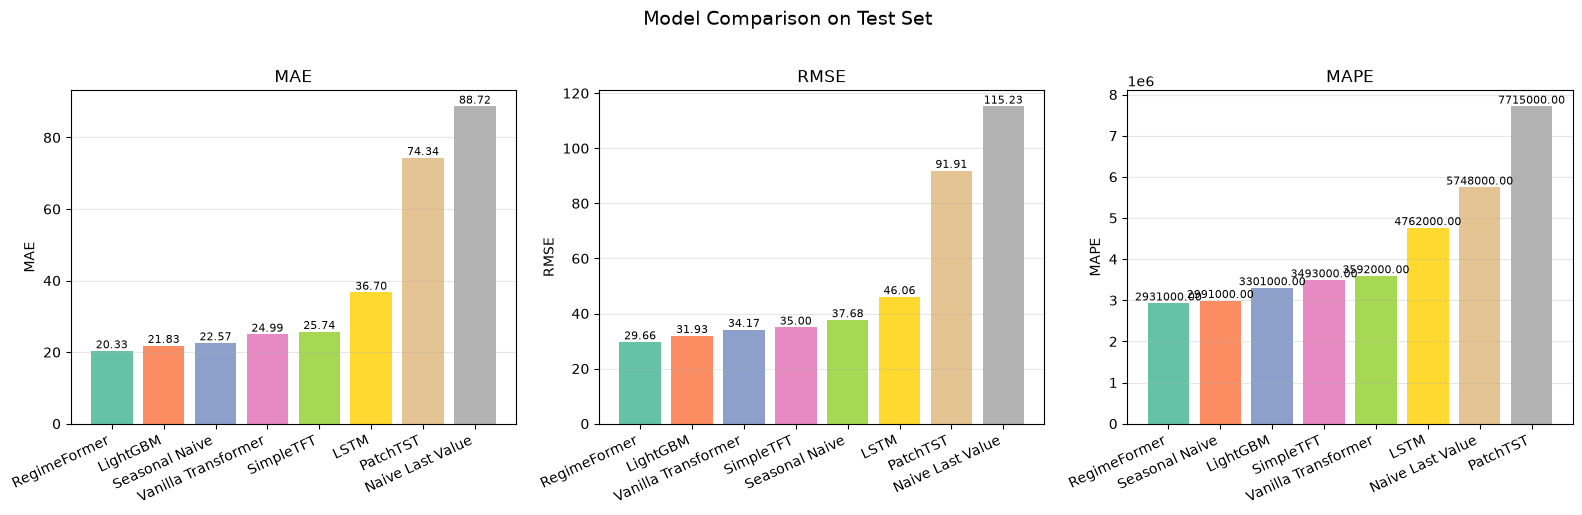

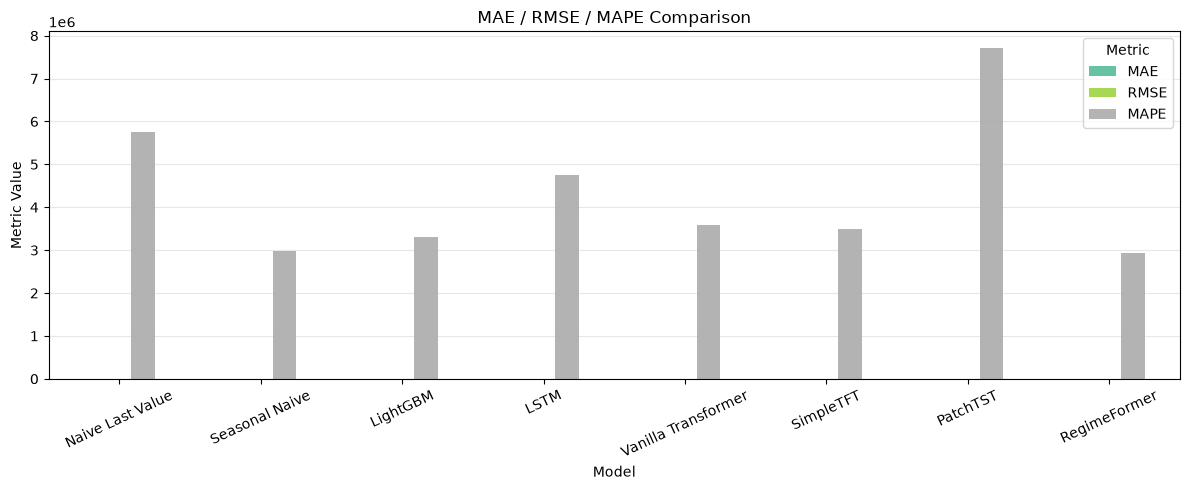

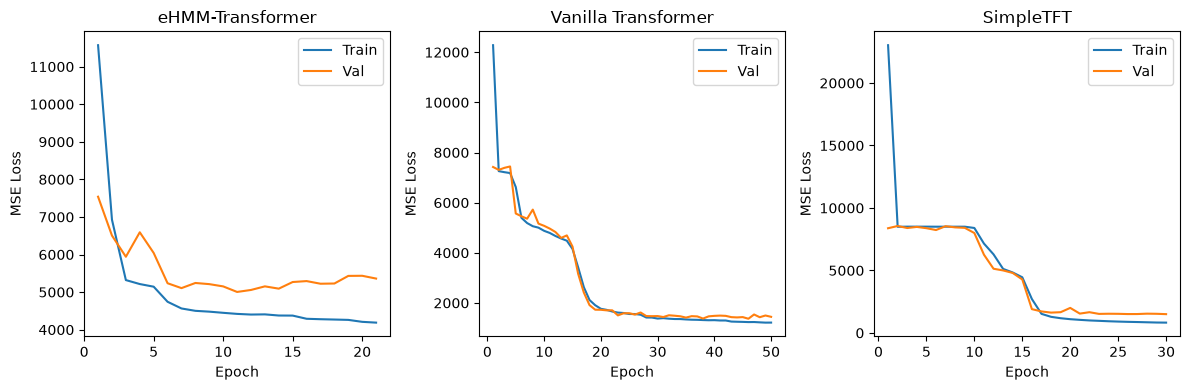

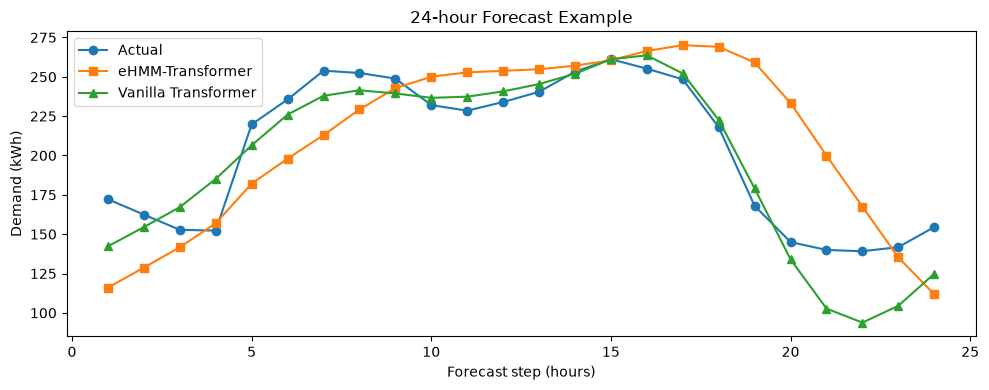

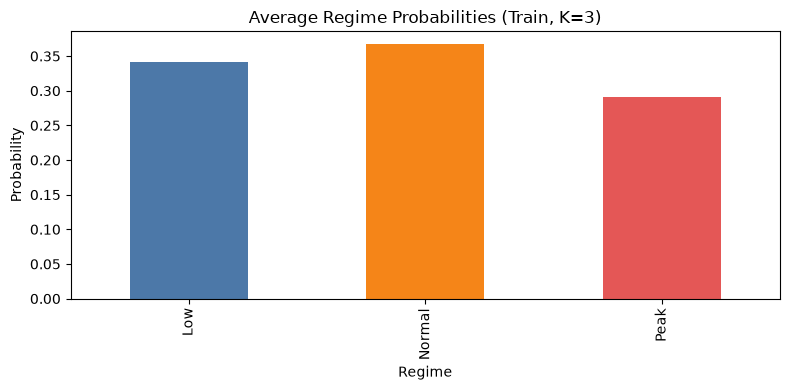

Saved comparison artifacts:
  ✓ /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/metrics.csv
  ✓ /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/metrics_ranked.csv
  ✓ /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/run_manifest.json
  ✓ /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/figures/metrics_comparison.png
  ✓ /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/figures/metrics_comparison_grouped.png
  ✓ /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/figures/training_loss_curves.png
  ✓ /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

if "FIG_DIR" not in globals():
    ROOT = Path("..").resolve()
    OUTPUT_DIR = ROOT / "outputs"
    FIG_DIR = OUTPUT_DIR / "figures"
    PRED_DIR = OUTPUT_DIR / "predictions"
    for d in [FIG_DIR, PRED_DIR]:
        d.mkdir(parents=True, exist_ok=True)

if "metrics_df" not in globals() or metrics_df is None or len(metrics_df) == 0:
    metrics_path = OUTPUT_DIR / "metrics.csv"
    if metrics_path.exists():
        metrics_df = pd.read_csv(metrics_path, index_col=0)
    else:
        raise RuntimeError("Chạy cell evaluation (Phase 7) trước khi vẽ biểu đồ.")

# --- 1) Bar charts so sánh metrics ---
compare_metrics = ["MAE", "RMSE", "MAPE"]
plot_df = metrics_df[compare_metrics].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
colors = plt.cm.Set2(np.linspace(0, 1, len(plot_df)))

for ax, metric in zip(axes, compare_metrics):
    values = plot_df[metric].sort_values()
    bars = ax.bar(range(len(values)), values.values, color=colors[: len(values)])
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(values.index, rotation=25, ha="right")
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, values.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.2f}",
                ha="center", va="bottom", fontsize=8)

fig.suptitle("Model Comparison on Test Set", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

ax = plot_df.plot(kind="bar", figsize=(12, 5), rot=25, colormap="Set2")
ax.set_title("MAE / RMSE / MAPE Comparison")
ax.set_ylabel("Metric Value")
ax.set_xlabel("Model")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Metric")
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(FIG_DIR / "metrics_comparison_grouped.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 1b) Horizon sweep MAE — all models ---
_horizon_path = OUTPUT_DIR / "metrics_by_horizon.csv"
if _horizon_path.exists():
    hdf = pd.read_csv(_horizon_path)
    h_mae = hdf.pivot(index="model", columns="horizon", values="MAE").sort_index()
    if len(h_mae) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        markers = ["o", "s", "^", "D", "v", "P", "*"]
        for i, model in enumerate(h_mae.index):
            ax.plot(
                h_mae.columns,
                h_mae.loc[model].values,
                marker=markers[i % len(markers)],
                linewidth=2,
                label=model,
            )
        ax.set_xlabel("Forecast horizon (hours)")
        ax.set_ylabel("MAE")
        ax.set_title("MAE by Forecast Horizon — All Models")
        ax.set_xticks(h_mae.columns)
        ax.set_xticklabels([f"H={int(h)}h" for h in h_mae.columns])
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        fig.savefig(FIG_DIR / "metrics_by_horizon.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved → metrics_by_horizon.png")

# --- 2) Training curves từ file history (không cần model trong RAM) ---
history_specs = [
    ("eHMM-Transformer", "ehmm_transformer_history.npz"),
    ("Vanilla Transformer", "vanilla_transformer_history.npz"),
    ("PatchTST", "patchtst_history.npz"),
    ("SimpleTFT", "simple_tft_history.npz"),
    ("iTransformer", "itransformer_history.npz"),
]
histories = []
for name, fname in history_specs:
    path = PRED_DIR / fname
    if path.exists():
        data = np.load(path)
        histories.append((name, {"train_loss": data["train_loss"], "val_loss": data["val_loss"]}))

if histories:
    n = len(histories)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]
    for ax, (name, history) in zip(axes, histories):
        epochs = range(1, len(history["train_loss"]) + 1)
        ax.plot(epochs, history["train_loss"], label="Train")
        ax.plot(epochs, history["val_loss"], label="Val")
        ax.set_title(name)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE Loss")
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / "training_loss_curves.png", dpi=150)
    plt.show()
else:
    print("No training history files — skip loss curves")

# --- 3) 24h forecast example từ .npz cache ---
prop_pred, prop_true = load_pred_arrays("ehmm_transformer")
van_pred, van_true = load_pred_arrays("vanilla_transformer")

if prop_pred is not None and van_pred is not None:
    idx = 0
    horizon = prop_pred.shape[1]
    steps = np.arange(1, horizon + 1)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(steps, prop_true[idx], label="Actual", marker="o")
    ax.plot(steps, prop_pred[idx], label="eHMM-Transformer", marker="s")
    ax.plot(steps, van_pred[idx], label="Vanilla Transformer", marker="^")
    ax.set_xlabel("Forecast step (hours)")
    ax.set_ylabel("Demand (kWh)")
    ax.set_title("24-hour Forecast Example")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / "prediction_plot.png", dpi=150)
    plt.show()

    # Export flat predictions cho phân tích ngoài notebook
    export = {"y_true": flatten_forecasts(prop_true), "ehmm_transformer": flatten_forecasts(prop_pred)}
    if van_pred is not None:
        export["vanilla_transformer"] = flatten_forecasts(van_pred)
    for label, key in [("PatchTST", "patchtst"), ("SimpleTFT", "simple_tft"), ("iTransformer", "itransformer"), ("LightGBM", "lightgbm")]:
        p, _ = load_pred_arrays(key)
        if p is not None:
            export[key] = flatten_forecasts(p)
    pd.DataFrame(export).to_csv(PRED_DIR / "test_predictions.csv", index=False)

# --- 4) Regime distribution ---
if "train_df" in globals() and "REGIME_NAMES" in globals() and all(c in train_df.columns for c in REGIME_NAMES):
    regime_means = train_df[REGIME_NAMES].mean()
    # Pretty labels from column names: regime_low_prob -> Low, etc.
    regime_means.index = [
        c.replace("regime_", "").replace("_prob", "").replace("_", " ").title()
        for c in REGIME_NAMES
    ]
    colors = ["#4C78A8", "#F58518", "#E45756", "#72B7B2", "#B279A2"][: len(REGIME_NAMES)]
    fig, ax = plt.subplots(figsize=(8, 4))
    regime_means.plot(kind="bar", ax=ax, color=colors)
    ax.set_title(f"Average Regime Probabilities (Train, K={len(REGIME_NAMES)})")
    ax.set_ylabel("Probability")
    ax.set_xlabel("Regime")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "regime_distribution.png", dpi=150)
    plt.show()

print("Saved comparison artifacts:")
for path in [
    OUTPUT_DIR / "metrics.csv",
    OUTPUT_DIR / "metrics_ranked.csv",
    OUTPUT_DIR / "run_manifest.json",
    FIG_DIR / "metrics_comparison.png",
    FIG_DIR / "metrics_comparison_grouped.png",
    FIG_DIR / "training_loss_curves.png",
    FIG_DIR / "prediction_plot.png",
    FIG_DIR / "regime_distribution.png",
    PRED_DIR / "test_predictions.csv",
]:
    if path.exists():
        print(f"  ✓ {path}")
    else:
        print(f"  - {path} (chưa có)")
